In [37]:
# use extension to auto reload modules
%load_ext autoreload
%autoreload 2
# %load_ext line_profiler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import logging
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
import seaborn as sns
import numpy as np
import scipy
import scipy.stats
import sktime
import statsmodels.api as sm
import statsmodels.formula.api as smf


The first use-cases in mind when playing with these bike counts data are the following : 
- Compare two periods (most likly, two years) for the same counter and decide if there is statistical evidence for a change : 
   * in the overall level of use of the bike-path, besides variations which would be explained by uncontrolled exogeneous effects such as weather, calendar etc. This could be used, e.g., to measure the "actual" evolution of the number of cyclists and evaluate the effect of modifications in the cycling policy/infrastructure.
   * In the behaviour of cyclists (possibly due to cultural or demographic variations among practitionners), such as how they react to rain, temperature or even vacations.
- Compare two sites in terms of how their level of use changes on average with identified parameters of interest such as weather, vacations etc. Possible questions adressed by this comparisons would be : 
   * Are cyclists using the cycle-path in Nice more sensitive to rain than in Paris ?
   * Does Paris loose cyclists in summer vacations while Nice gains some ?

Other use-cases could be simple day/week ahead count prediction, or abnormal/unusual count detection which could be an evidence for a special event or counter malfunction, justifying investigation.

Anyway, before engineering or selecting features, building models etc., this notebook starts by having a look at the data involved in this project. 
As explained in the data-retrieval part, some dependencies between the daily bike counts and other exogeneous variables are suspected.
Accordingly, this notebook explores these dependencies in more or less complex manners, before moving on to modelling in the next studies.

# Simple dataviz

First, the static data scrapped from eco-counter and fetched from the web are retrieved.

In [39]:
# find all the parquet files ending by "_bike_counts_with_weather.parquet" in the data/ folder
# load them and put the resulting table in a dict where the key is the prefix of the file name
data_folder = "data/"
data_counters = {}
for file_name in os.listdir(data_folder):
    if file_name.endswith("_bike_counts_with_weather.parquet"):
        nickname_clean = file_name.replace("_bike_counts_with_weather.parquet", "")
        data_counters[nickname_clean] = (pd.read_parquet(os.path.join(data_folder, file_name))
                                         .sort_index()
                                         .loc["2021":,:]) # drop 2020 data because of covid

bike_counters = sorted(list(data_counters.keys()))

Gathering all data from all counters is created, with a new column denoting the counter nickname.

In [40]:
# regroup all dataframes in the data_counters dict in a single dataframe with an additional column "counter" that contains the nickname of the counter
data_all_counters = pd.concat(
    [df.assign(counter=nickname) for nickname, df in data_counters.items()],
).sort_index().loc["2021":,:] # drop 2020 data because of covid
data_all_counters

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations,counter
date,,,,,,,,,,,,,,,,,,,
2021-01-01,2.2,0.6,4.1,0.2,1.0,<NA>,7.6,18.5,1010.8,<NA>,2037.0,895.0,1142.0,False,False,Friday,True,True,paris_sebastopol
2021-01-01,6.9,5.5,9.3,11.2,<NA>,<NA>,19.1,55.0,1006.0,<NA>,166.0,95.0,71.0,True,False,Friday,True,True,nice_carras
2021-01-02,2.2,-0.3,4.6,0.0,<NA>,<NA>,5.3,21.0,1014.9,<NA>,3987.0,1793.0,2194.0,False,True,Saturday,False,True,paris_sebastopol
2021-01-02,7.4,5.8,11.2,23.9,<NA>,<NA>,18.7,50.0,1001.4,<NA>,349.0,206.0,143.0,True,True,Saturday,False,True,nice_carras
2021-01-03,3.4,2.8,4.3,0.0,<NA>,<NA>,8.6,31.0,1014.2,<NA>,3306.0,1386.0,1920.0,False,True,Sunday,False,True,paris_sebastopol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-08,9.6,7.4,11.1,15.6,<NA>,<NA>,18.5,38.9,1006.8,31.0,1228.0,588.0,640.0,True,True,Sunday,False,False,nice_carras
2026-02-08,9.6,7.4,11.1,15.6,<NA>,<NA>,18.5,38.9,1006.8,31.0,617.0,297.0,320.0,True,True,Sunday,False,False,cagnes_sur_mer
2026-02-09,10.6,8.9,11.7,11.0,<NA>,<NA>,14.4,27.8,1006.2,33.0,3086.0,1482.0,1604.0,True,False,Monday,False,False,nice_carras


In [41]:
data_paris = data_counters["paris_sebastopol"]
data_paris.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations
date,,,,,,,,,,,,,,,,,,
2021-01-01,2.2,0.6,4.1,0.2,1.0,<NA>,7.6,18.5,1010.8,<NA>,2037,895,1142.0,False,False,Friday,True,True
2021-01-02,2.2,-0.3,4.6,0.0,<NA>,<NA>,5.3,21.0,1014.9,<NA>,3987,1793,2194.0,False,True,Saturday,False,True
2021-01-03,3.4,2.8,4.3,0.0,<NA>,<NA>,8.6,31.0,1014.2,<NA>,3306,1386,1920.0,False,True,Sunday,False,True
2021-01-04,3.1,2.7,3.6,0.0,<NA>,<NA>,12.5,41.0,1013.6,<NA>,6471,2663,3808.0,False,False,Monday,False,False
2021-01-05,3.1,2.8,3.3,0.0,<NA>,<NA>,12.8,31.5,1014.8,<NA>,7490,3115,4375.0,False,False,Tuesday,False,False


In this first interactive plot, one can get a feeling of the variations of the bike count over time for each site. 
The mean day temperature is plotted as well to get a first feeling of seasons and how they can be related to the bike count depending on the site.

In [42]:
count_plot = data_all_counters.hvplot.line(
    y="count",
    width=1000,
    height=600,
    title="Bike counts over time at a counter",
    ylabel="Bike counts",
    groupby="counter",
    hover_cols=['prcp', 'weekday','is_holiday', 'is_vacations', 'tavg'],
    label="Bike count",
    )
count_plot
temp_plot = data_all_counters.hvplot.line(
    y="tavg",
    yaxis="right",
    color="firebrick",
    ylabel="Avg temperature (C)",
    groupby="counter",
    line_dash='dashed',
    hover_cols=['tavg', 'tmin', 'tmax', 'count'],
    label="Avg temperature",
    )
(count_plot * temp_plot).opts(
    multi_y=True,
    legend_position="top_left",
    legend_opts={"click_policy": "mute"}   # click legend to show/hide series
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'1e20c795-9a6d-42cd-b6bf-fcfc821523f3': {'version…

From this first plot, one can already see some common features and differences between these three sites :
- all of them seem to have a certain yearly (weekly when zooming?) seasonlity;
- the bike count seems correlated with the external temperature;
- but the time in the year also seem to have an effect. E. g. in Paris, the evolution of the count in summer seems much different that the one in Nice.

# Seasonality and effect of the day of week

Plotting the autocorrelation of the bike-count timeseries is a first way to grab an idea of the importance of the seasonality in the data.

## ACF plot

In Paris Sebastopol, a major commuting cycleway, the data shows an expected autocorrelation with the previous day, as well as with the same day of the previous week (lag 7).
Yealrly seasonality can be guessed as well.

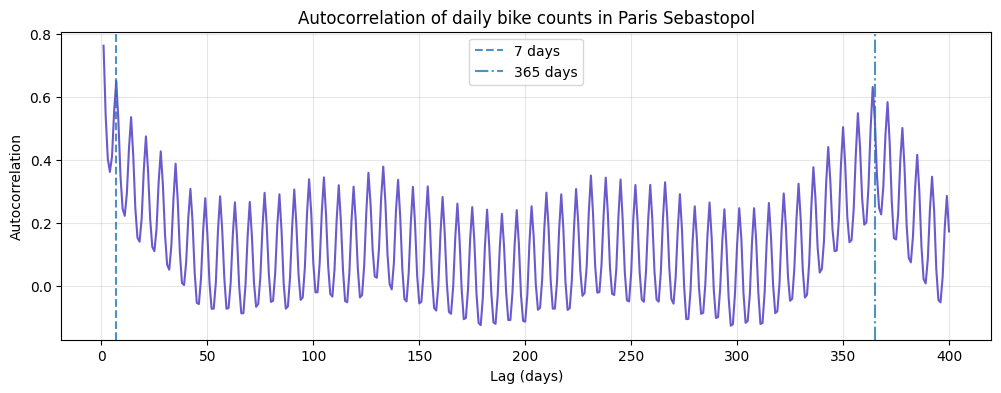

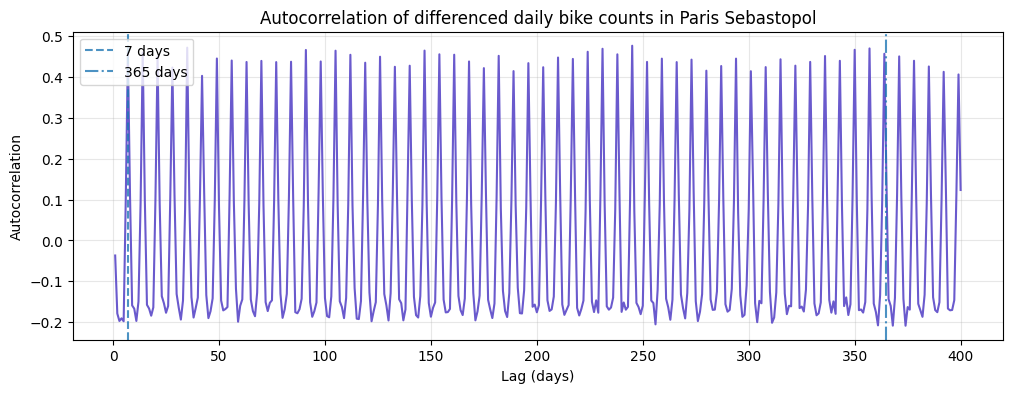

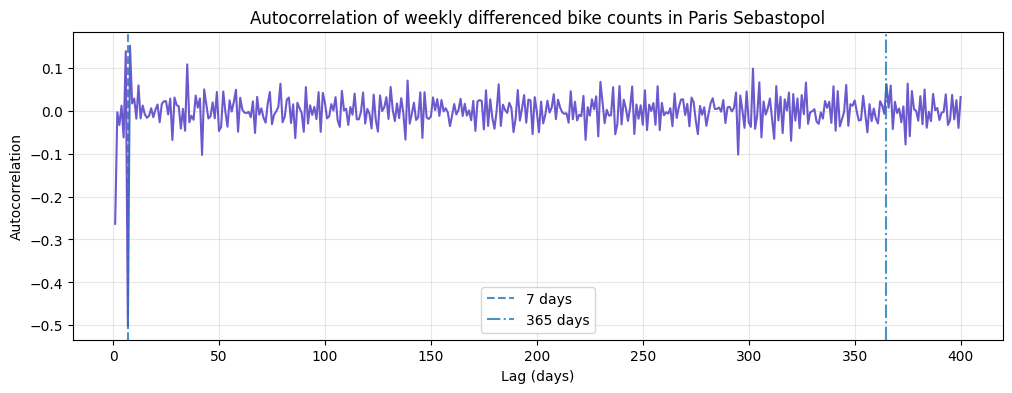

In [43]:
def plot_acf(series, max_lag=400, title="Autocorrelation", mark_lags=(7, 365)):
    series = series.dropna()
    acf_vals = [series.autocorr(lag) for lag in range(1, max_lag + 1)]
    plt.figure(figsize=(12, 4))
    plt.plot(range(1, max_lag + 1), acf_vals, color="slateblue")
    line_styles = ["--", "-.", ":", (0, (5, 1))]
    for i, lag in enumerate(mark_lags):
        plt.axvline(lag, linestyle=line_styles[i % len(line_styles)], alpha=0.8, label=f"{lag} days")
    plt.title(title)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.grid(True, alpha=0.3)
    plt.legend()

# example usage
plot_acf(data_paris["count"], max_lag=400, title="Autocorrelation of daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff(), max_lag=400, title="Autocorrelation of differenced daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff().diff(periods=7).dropna(), max_lag=400, title="Autocorrelation of weekly differenced bike counts in Paris Sebastopol")

The plot can aslo be done with sktim which provides a view of PACF but is a bit less nice.

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

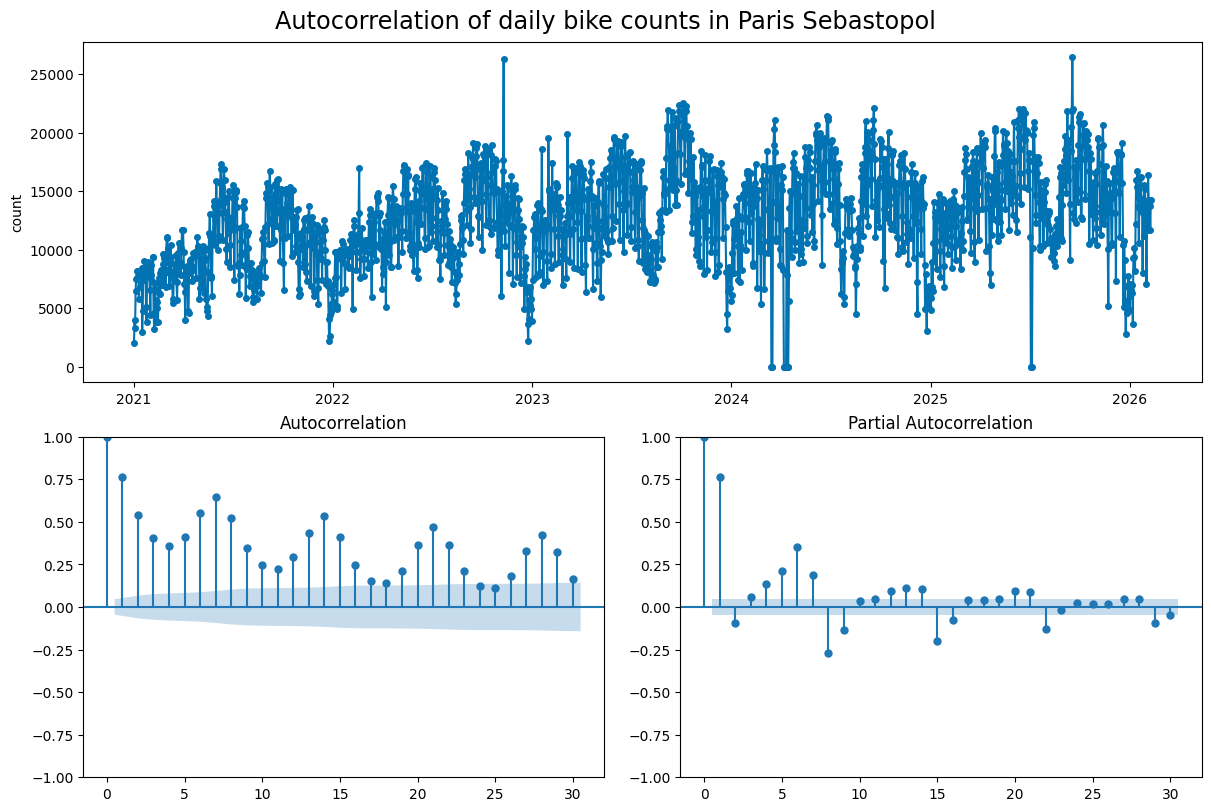

In [44]:
sktime.utils.plotting.plot_correlations(data_paris["count"], lags=30, suptitle="Autocorrelation of daily bike counts in Paris Sebastopol")

Conversely to Paris, the autocorrelation of the bike counts in the counters in Nice and Cagnes-sur-Mer have a much less obvious 7 days seasonality.

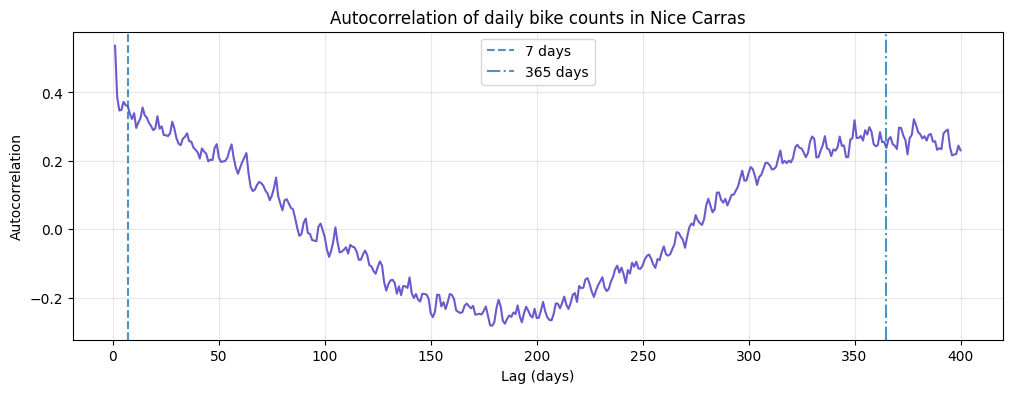

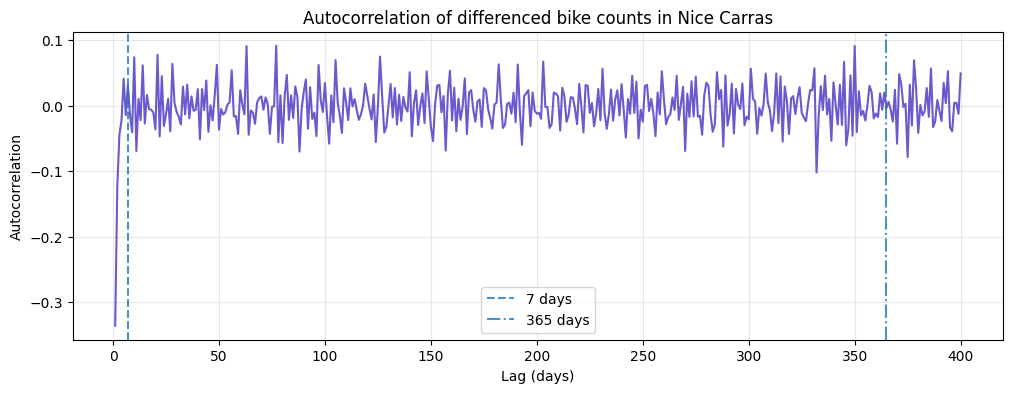

In [45]:
# example usage
plot_acf(data_counters['nice_carras']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Nice Carras")
plot_acf(data_counters['nice_carras']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of differenced bike counts in Nice Carras")

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

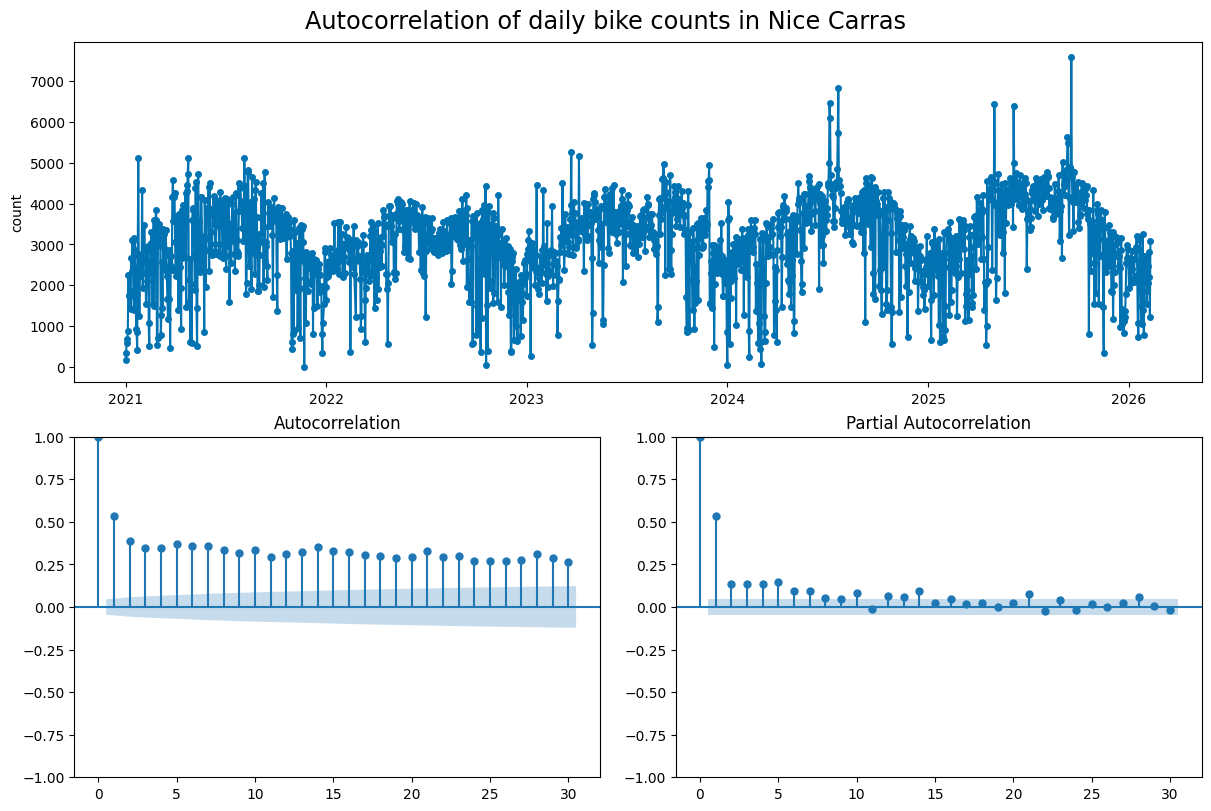

In [46]:
sktime.utils.plotting.plot_correlations(data_counters['nice_carras']['count'].dropna(),
                                        lags=30,
                                        suptitle="Autocorrelation of daily bike counts in Nice Carras")

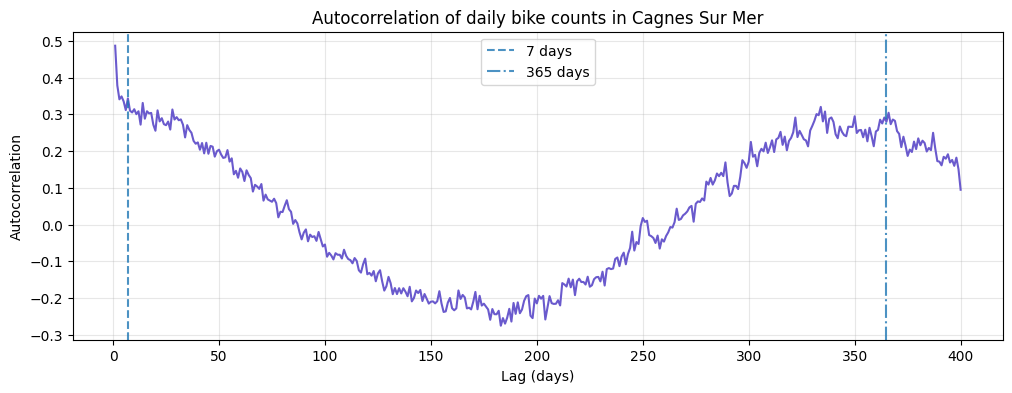

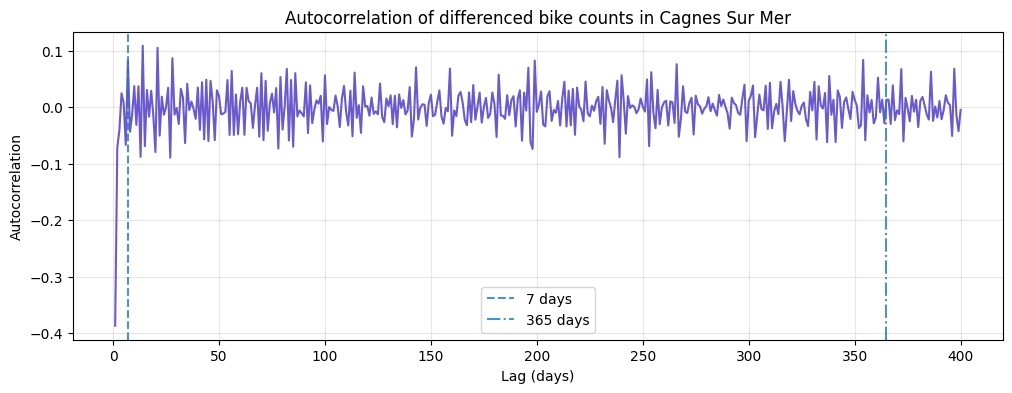

In [47]:
# example usage
plot_acf(data_counters['cagnes_sur_mer']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Cagnes Sur Mer")
plot_acf(data_counters['cagnes_sur_mer']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of differenced bike counts in Cagnes Sur Mer")

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

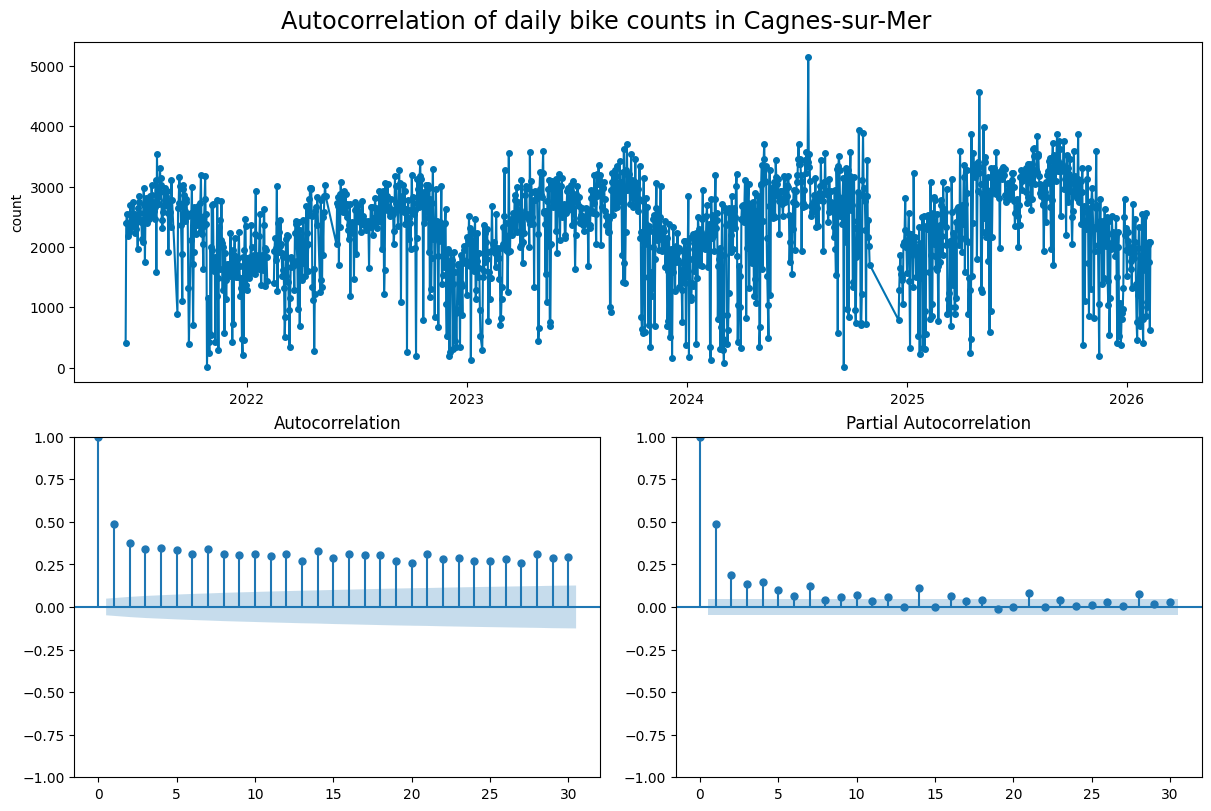

In [48]:
sktime.utils.plotting.plot_correlations(data_counters['cagnes_sur_mer']['count'].dropna(),
                                        lags=30,
                                        suptitle="Autocorrelation of daily bike counts in Cagnes-sur-Mer")

From these observations, a strong weekly pattern should be expected in Paris while a less obvious one is expected in Nice and Cagnes (but still, one can guess a small effect in the PACF plots).

There is also a strong and expected autocorrelation of the timeseries at lag 1 (weather among other things).

## Weekday effect

Representing the bike counts as box plots for each day of the week and each counter shows, indeed, a more obvious pattern in Paris.

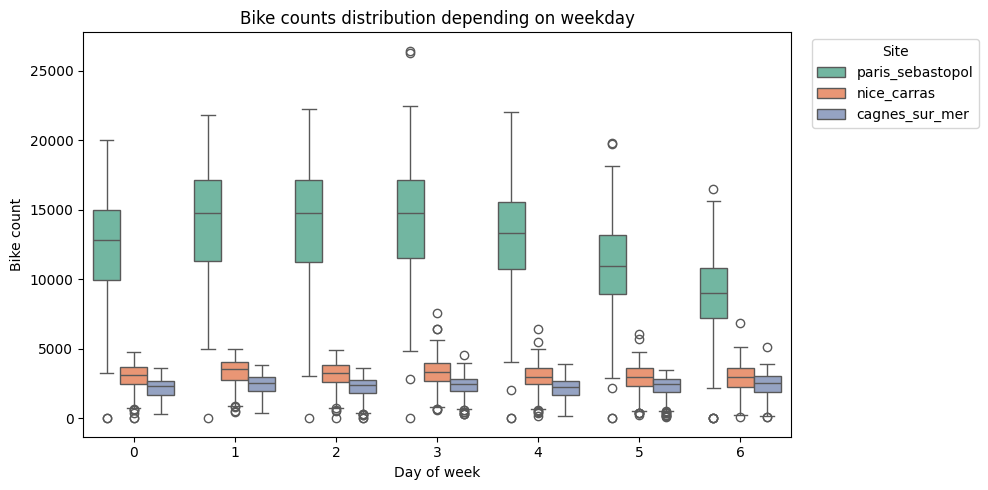

In [49]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=plot_data,
    x="weekday",
    y="count",
    hue="counter",
    palette="Set2",
)
plt.title("Bike counts distribution depending on weekday")
plt.xlabel("Day of week")
plt.ylabel("Bike count")
plt.legend(title="Site", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

As the frequentation of each site can be very different, and the counts display a few outliers, a normalized version of the bike counts is used below, by scaling the count by the 95th percentile of the counts for each site.

In [50]:
data_all_counters.groupby("counter")["count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
counter,,,,,,,,,,,
cagnes_sur_mer,1611.0,2281.612663,778.036578,12.0,1159.0,1832.00,2421.0,2830.5,3159.0,3321.50,5145.0
nice_carras,1862.0,3073.103115,1004.175812,6.0,1671.5,2493.75,3176.0,3781.5,4232.9,4476.75,7585.0
paris_sebastopol,1866.0,12636.016613,4148.928968,0.0,7388.5,9761.00,12642.5,15630.0,17995.5,19353.50,26443.0


In [51]:
q95_by_counter = data_all_counters.groupby("counter")["count"].transform(lambda s: s.quantile(0.95))
data_all_counters["normalized_count"] = data_all_counters["count"] / q95_by_counter
data_all_counters[["count", "normalized_count", "counter"]].head()

,count,normalized_count,counter
date,,,
2021-01-01,2037.0,0.105252,paris_sebastopol
2021-01-01,166.0,0.037080,nice_carras
2021-01-02,3987.0,0.206009,paris_sebastopol
2021-01-02,349.0,0.077958,nice_carras
2021-01-03,3306.0,0.170822,paris_sebastopol


The plot below represents the daily counts distribution for each counter, scaled by the 95% quantile of each counter's dataset.

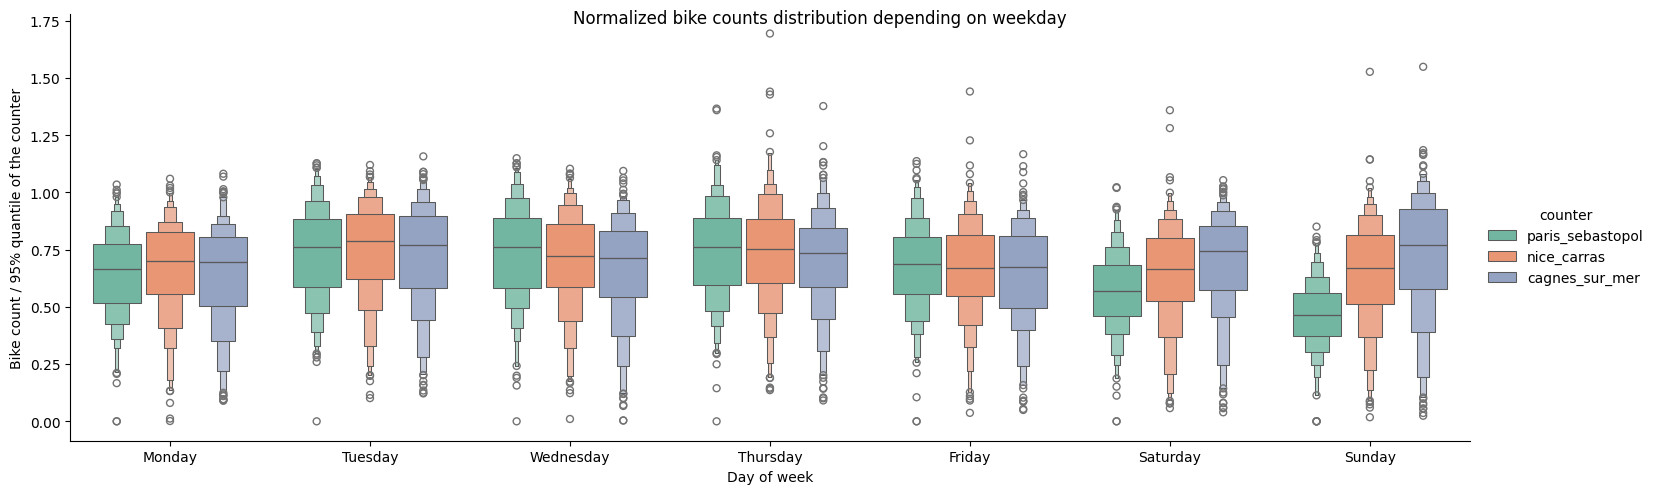

In [52]:
plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week
plot_data["day_name"] = pd.Categorical(
    plot_data["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weekday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

In the plot above, one can guess some weekly patterns and their differences or common points between counters. 

Splitting the plots by counter below gives a better insight of the pattern for each counter.

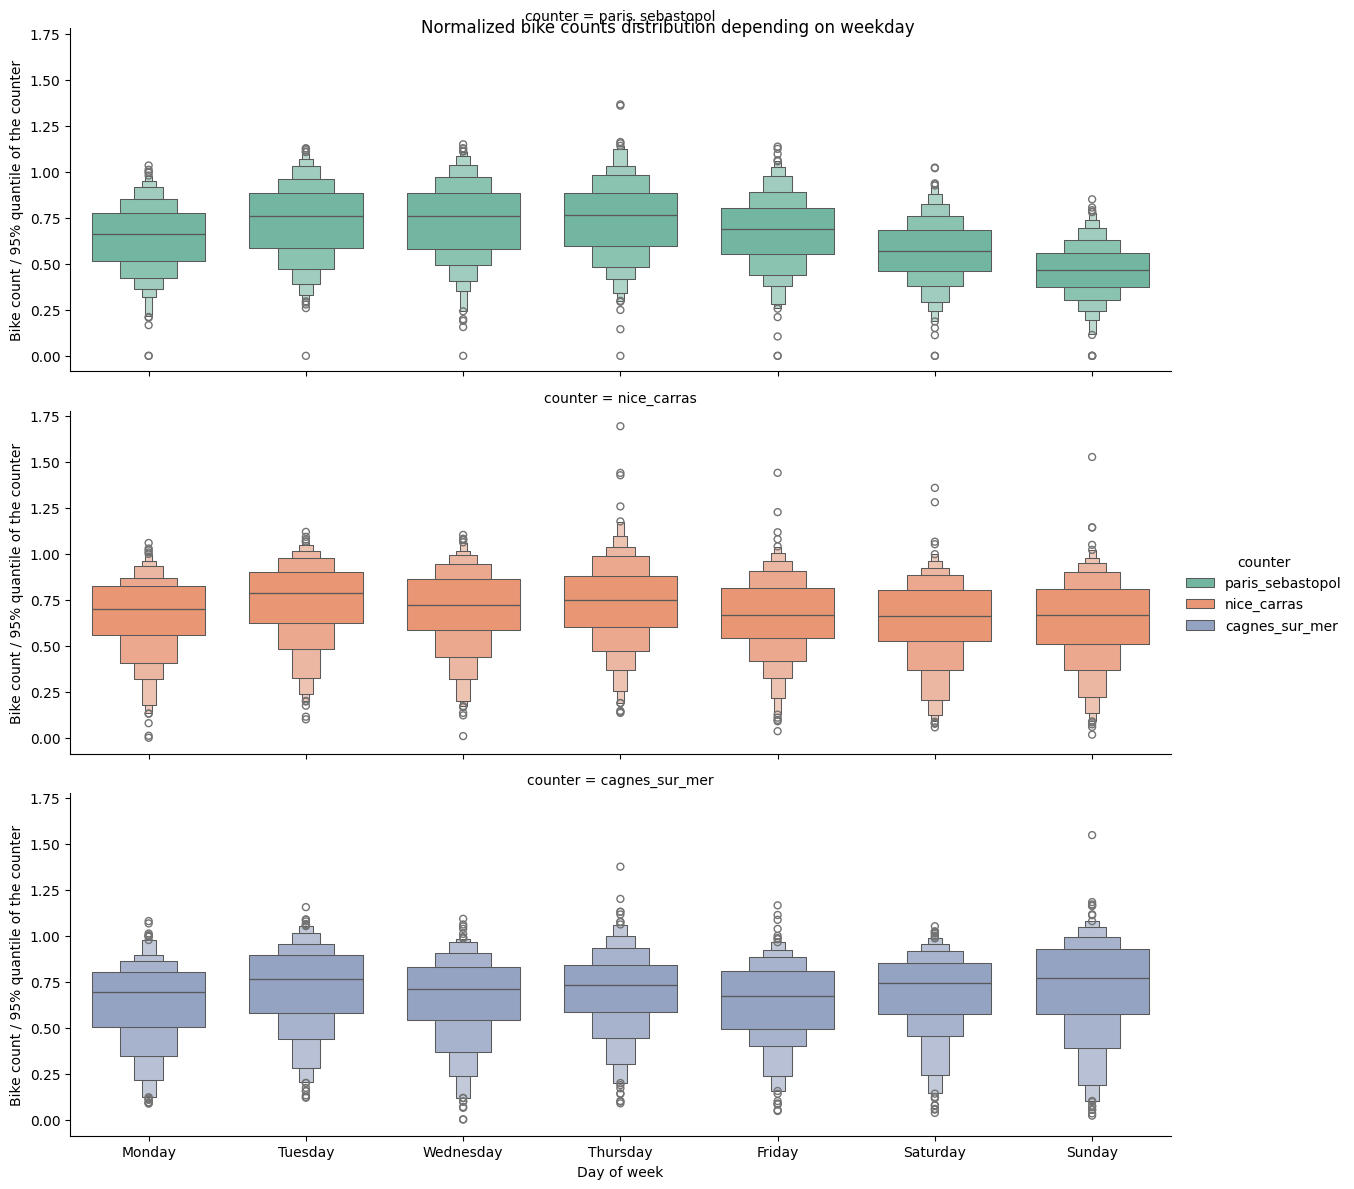

In [53]:
boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=4,
    aspect=3,
    row="counter",
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weekday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

It's interesting to see that daily patterns seem to exist and show some similarities from Monday to Friday for all counters.

However, the weekends seem to have different patterns depending on the counter, how was guessed in the very first dataviz when retrieving the data : 
- In Paris Sebastopol, well-known to be mainly used by commuters, weekends are much quieter.
- In Cagnes-sur-Mer and Nice, where the seaside is widely used by commuters, but also by leisure riders, the difference is much less obvious.

Examinating the hourly profiles depending on the day and site could give more insight about the kind of users in each case, but unfortunately, this data is not available on the Eco Counter website.

The effect of weekday could be investigated in a more quantitative manner, and a simple look at the descriptive statistics for each day and counter already provides another point of view, as illustrated below.

Using ANOVA or any related method adapted to the distribution of the data, with the right post-hoc analysis would help figuring out more accurately the patterns, but this is not yet the goal of this notebook, which is rather focused on getting a first insight of the parameters of interest to compare two periods or predict a future count.

In [54]:
plot_data.groupby(["counter", "day_name"])["normalized_count"].describe()

/tmp/ipykernel_28070/4266291487.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "day_name"])["normalized_count"].describe()


count      mean       std       min       25%  \
counter          day_name                                                   
cagnes_sur_mer   Monday     231.0  0.643401  0.223652  0.089719  0.503538   
                 Tuesday    230.0  0.723121  0.229239  0.121933  0.582117   
                 Wednesday  231.0  0.666458  0.232670  0.003613  0.544633   
                 Thursday   231.0  0.706932  0.222487  0.091224  0.587686   
                 Friday     230.0  0.644531  0.221686  0.049676  0.496011   
                 Saturday   229.0  0.694266  0.220784  0.039440  0.575342   
                 Sunday     229.0  0.730159  0.271569  0.024387  0.577751   
nice_carras      Monday     266.0  0.664309  0.209984  0.001340  0.557045   
                 Tuesday    265.0  0.742258  0.218492  0.101413  0.623220   
                 Wednesday  265.0  0.702242  0.217145  0.010275  0.585469   
                 Thursday   266.0  0.736888  0.229637  0.136260  0.602502   
                 Friday     267.0  0.667080  0.213701  0.037080  0.545485   
                 Saturday   266.0  0.642832  0.224871  0.057631  0.524990   
                 Sunday     267.0  0.650080  0.235235  0.017870  0.510862   
paris_sebastopol Monday     267.0  0.646062  0.185452  0.000000  0.514816   
                 Tuesday    266.0  0.734553  0.207636  0.000000  0.585656   
                 Wednesday  266.0  0.733974  0.211015  0.000000  0.581871   
                 Thursday   266.0  0.743302  0.213829  0.000000  0.597192   
                 Friday     267.0  0.675861  0.197964  0.000000  0.555946   
                 Saturday   267.0  0.571150  0.172594  0.000000  0.461622   
                 Sunday     267.0  0.466388  0.149568  0.000000  0.371638   

                                 50%       75%       max  
counter          day_name                                 
cagnes_sur_mer   Monday     0.698179  0.806262  1.081740  
                 Tuesday    0.768478  0.897561  1.157610  
                 Wednesday  0.713232  0.833358  1.094084  
                 Thursday   0.733705  0.845401  1.377390  
                 Friday     0.673340  0.808144  1.167244  
                 Saturday   0.743941  0.852928  1.053741  
                 Sunday     0.770435  0.927593  1.548999  
nice_carras      Monday     0.698945  0.826492  1.059921  
                 Tuesday    0.788742  0.904674  1.120009  
                 Wednesday  0.723963  0.862903  1.103702  
                 Thursday   0.750991  0.882727  1.694309  
                 Friday     0.670352  0.813425  1.441001  
                 Saturday   0.664210  0.803038  1.359245  
                 Sunday     0.668342  0.812196  1.527001  
paris_sebastopol Monday     0.663808  0.774098  1.034438  
                 Tuesday    0.761749  0.884375  1.127858  
                 Wednesday  0.761516  0.887501  1.149560  
                 Thursday   0.763118  0.886429  1.366316  
                 Friday     0.687834  0.804196  1.137004  
                 Saturday   0.567856  0.682719  1.022967  
                 Sunday     0.465807  0.558969  0.850699

# Vacations, holidays and other calendar exeptions

First, let take a look at the distribution of counts for each counter depending on the fact that a day is a holiday, during vacations or a "normal day".

A categorical variable is defined accordingly. To simplify, a holiday during vacations is just considered as a holiday, neglecting the combination of these features.

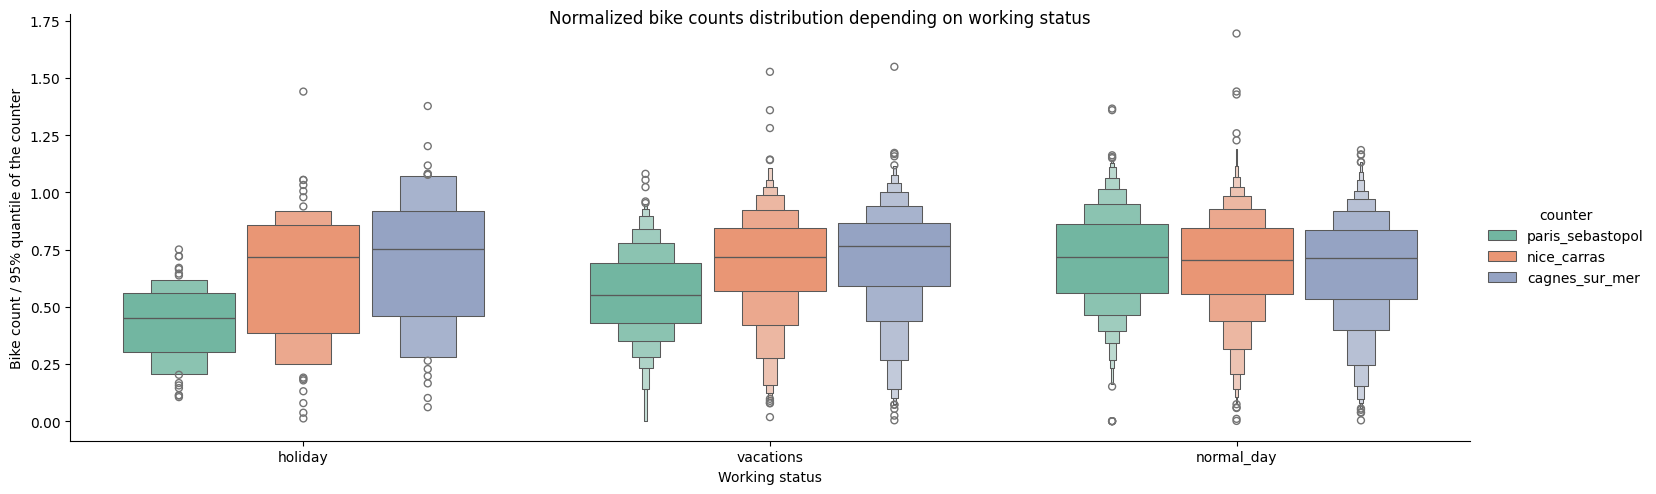

In [55]:
# Define "working status" categorical variable from the "is_holiday" and "is_vacations" boolean columns
working_status_order = ['holiday', 'vacations', 'normal_day']
plot_data["working_status"] = np.select(
    [
        plot_data["is_holiday"],
        plot_data["is_vacations"],
    ],
    [
        "holiday",
        "vacations",
    ],
    default="normal_day"
)
plot_data["working_status"] = pd.Categorical(
    plot_data["working_status"],
    categories=working_status_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="working_status",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on working status")
boxen.set_xlabels("Working status")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While a quantitative analysis would be needed to be more accurate, the plot above gives a good insight of what happens at these three locations, with the light of the prior knowledge about the nature of the data.
Once again, Paris Sebastopol shows a different pattern than Nice and Cagnes-sur-Mer.

In Paris, holidays and vacations seem to have a clear effect on the median count of cyclists : holidays are less busy than vacations, which are less busy than normal days. 

In Nice and Cagnes-sur-Mer (neighbouring counters), the effect on the median value is much less obvious (or inexistent). 
However, one can see that the **dispertion** of the counts for these counters during holidays is much higher.



In [56]:
plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()

/tmp/ipykernel_28070/1266729444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()


count      mean       std       min  \
counter          working_status                                         
cagnes_sur_mer   holiday           46.0  0.702125  0.324607  0.061117   
                 vacations        535.0  0.713363  0.231882  0.003914   
                 normal_day      1030.0  0.672510  0.229689  0.003613   
nice_carras      holiday           56.0  0.643053  0.303969  0.012062   
                 vacations        586.0  0.687214  0.226372  0.017870   
                 normal_day      1220.0  0.688088  0.219004  0.001340   
paris_sebastopol holiday           56.0  0.432402  0.170911  0.105252   
                 vacations        587.0  0.556102  0.187707  0.000000   
                 normal_day      1223.0  0.709466  0.204932  0.000000   

                                      25%       50%       75%       max  
counter          working_status                                          
cagnes_sur_mer   holiday         0.457700  0.754328  0.920217  1.377390  
                 vacations       0.591299  0.766220  0.864369  1.548999  
                 normal_day      0.535150  0.711275  0.835842  1.185007  
nice_carras      holiday         0.387111  0.719719  0.855587  1.440554  
                 vacations       0.569833  0.716368  0.846373  1.527001  
                 normal_day      0.554643  0.705311  0.843581  1.694309  
paris_sebastopol holiday         0.301095  0.450203  0.561836  0.750510  
                 vacations       0.430026  0.549358  0.690883  1.081200  
                 normal_day      0.559873  0.719043  0.862350  1.366316

Of course, this catagory is much less represented in the dataset, which could lead to higher variance.
But as the number of samples of holidays are already about 50 in each counter, and Paris and Nice have the same count of holiday samples, other causes deserve investigation.

In particular, it can be suspected that, provided the prior knowledge that leisure rides are more prominent in Nice and Cagnes, the effect of weather may be more important there on holidays.
Quantitative analysis should therefore investigate the effect of the interaction between weather and working status.

# Investigating the effect of weather

As noticed earlier, weather is likely a relevant parameter which should affect the bike counts : cyclists tend to be more enthusiastic to ride in mild and dry weather conditions!

The following cells, after curing a few missing data, represent the normalized count for each meter depending on the average day temperature, split by working status of the day. 
Days for which precipitations are greater than 0 are tagged as "rainy", and distinguished by a different color.

In [57]:
nan_rainy = plot_data.loc[plot_data["prcp"].isna(), :]

In [58]:
plot_data = plot_data.loc[~plot_data["prcp"].isna(), :]

In [59]:
plot_data.loc[:,'is_rainy'] = plot_data['prcp'] > 0.

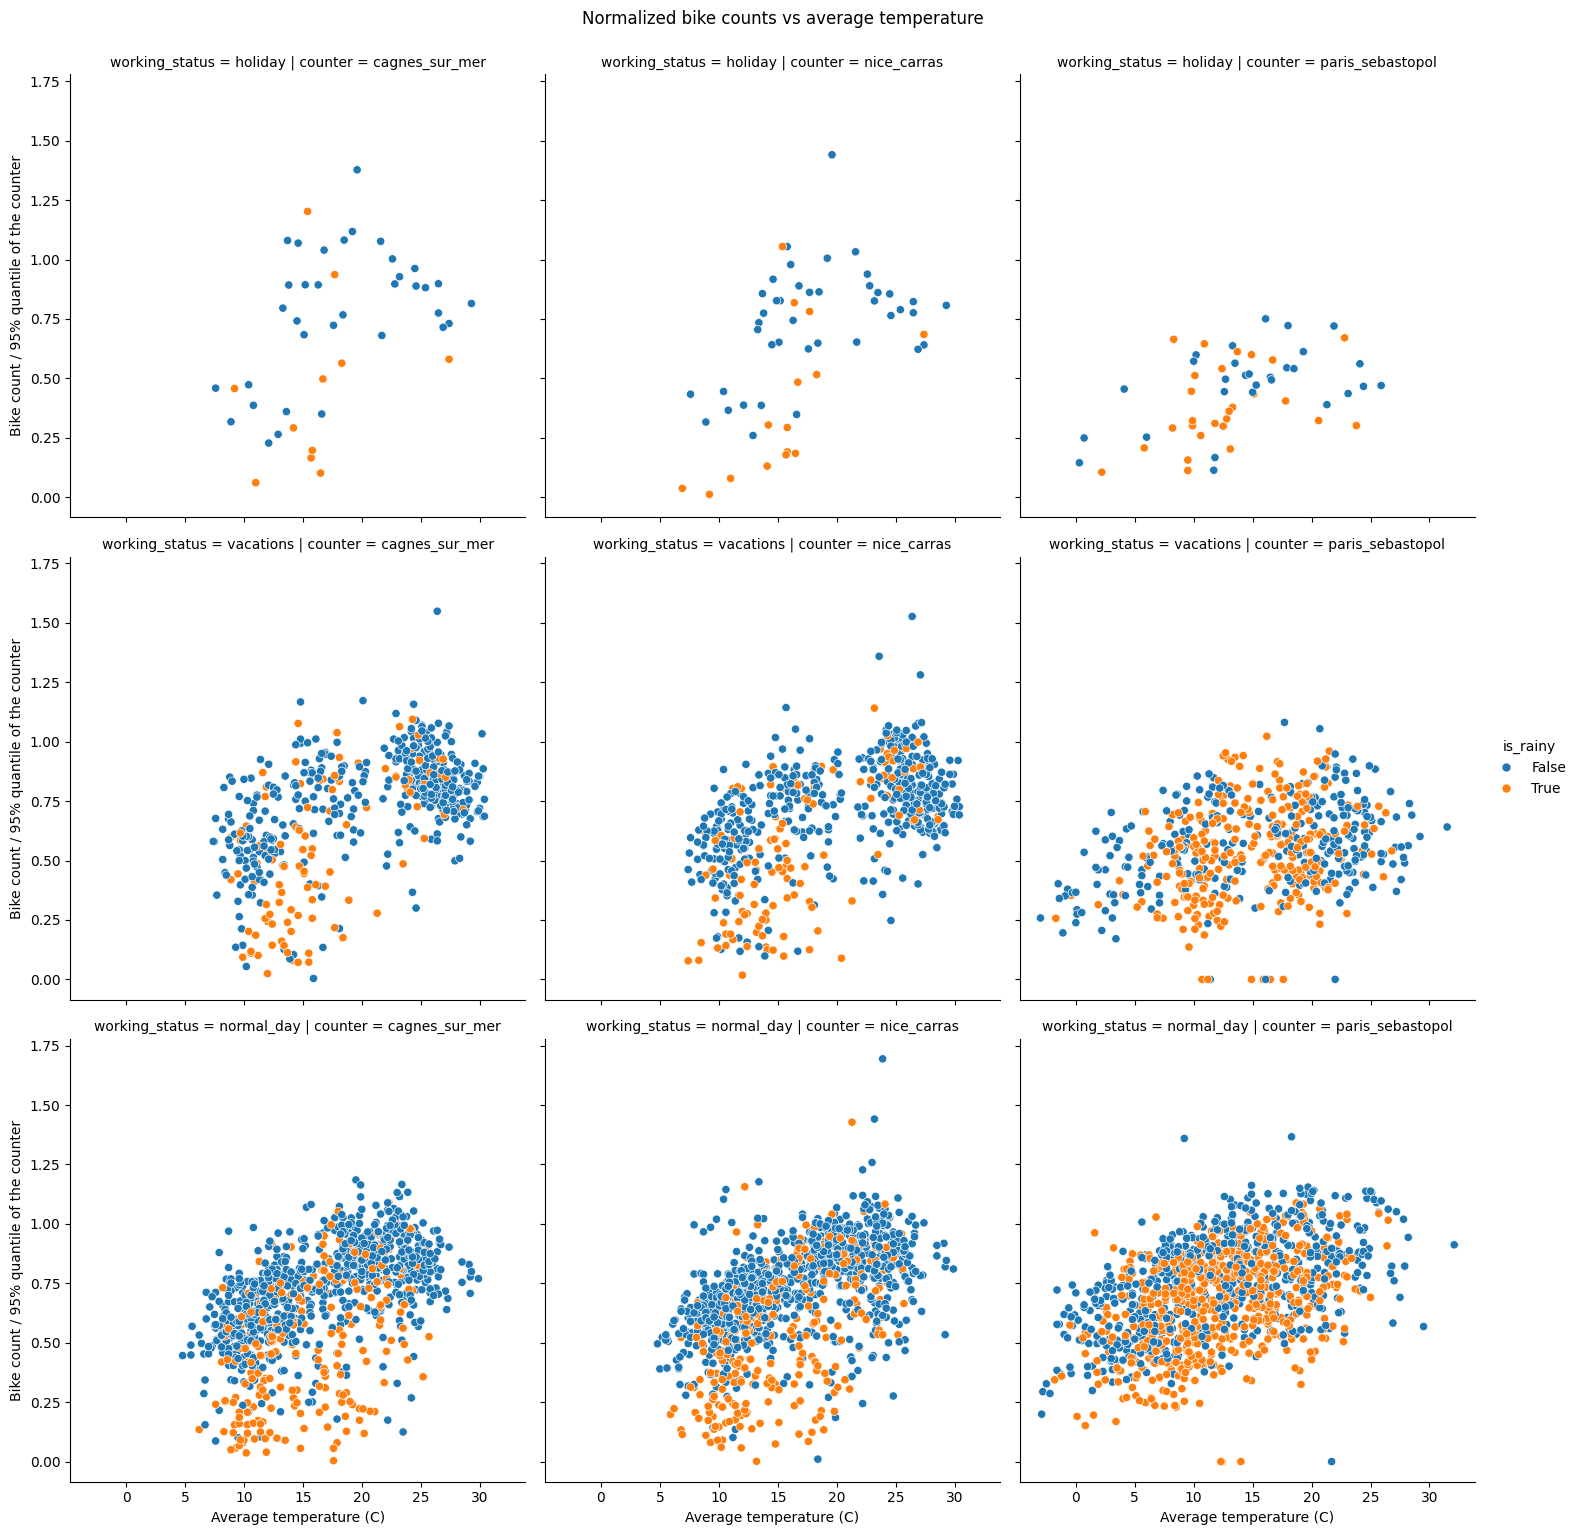

In [60]:
counter_order = sorted(plot_data["counter"].unique())

lm_graph = sns.relplot(
    data=plot_data,
    x="tavg",
    y="normalized_count",
    hue="is_rainy",
    row="working_status",
    col="counter",
    col_order=counter_order,
    )
lm_graph.fig.suptitle(f"Normalized bike counts vs average temperature", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While quantitative analysis is still not yet in the scope of this notebook, qualitative observations can already be done.

## Weather in Paris


Starting with Paris, on "normal days", temperature seem to have a clear positive correlation with the normalized bike count, and rain seems to have a negative effect on it.

The rainy and non rainy sets seem quiet entangled and do not display obvious differences in thermosensitivity, besides a vertical shift. 
This could be investigated more thouroughly later on, as the day of week was found to have an effect in Paris.

A few outliers can also be spotted :
- Zero values which could indicate a matfunction of the meter.
- A couple high values, which dates could be investigated in order to find if they match with sepcial events, or which could be just dumped if this kind of information isn't of interest.

Also, the slope of the thermosensitivity does not show an obvious variation between vacations, holidays and normal days (to be confirmed quantitativly).

Finally, the clustered structure of the plot for vacations can be noticed, which is explained by the correlation betwen the weather and the date in the year : vacations repeat periodically each year at the same time, with similar meteorological conditions.
This can create a bit of confusion regarding the effect of high average temperatures, maybe more easily understood in the plot below, where only non rainy days are represented to lat aside the effect that rain could have on the results.

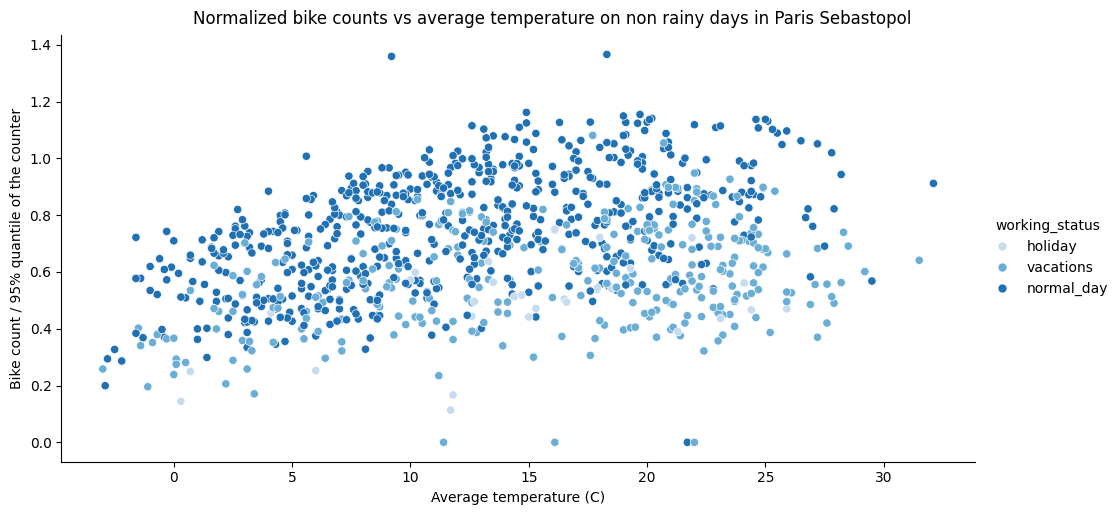

In [61]:
lm_graph = sns.relplot(
    data=plot_data.query("prcp == 0 and counter == 'paris_sebastopol'"),
    x="tavg",
    y="normalized_count",
    hue="working_status",
    aspect=2,
    palette="Blues",
)
lm_graph.figure.suptitle("Normalized bike counts vs average temperature on non rainy days in Paris Sebastopol", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

An interactive version below :

In [62]:
count_plot = plot_data.query("prcp == 0").hvplot.scatter(
    y="count",
    x="tavg",
    width=1000,
    height=600,
    title="Bike counts as a function of average temperature at a counter",
    xlabel="Average temperature (C)",
    ylabel="Bike counts",
    groupby="counter",
    by='working_status',
    hover_cols=['date', 'day_name', 'wspd', 'tavg'],
    label="Bike count",
    color=sns.color_palette("Blues", n_colors=len(working_status_order)).as_hex(),
    )
(count_plot).opts(
    legend_position="top_left",
    legend_opts={"click_policy": "mute"}   # click legend to show/hide series
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'44c33356-8ba6-403f-986b-9f31cee7d68e': {'version…

When the averaged temperature gets higher than about 20°C, one could assume from this plots the the number of cyclists stops increasing and, conversly, that the number of counted bikes drops as the temperature becomes hotter and hotter.

This is a plausible assumption, and it would make bike usage influenced by the thermal comfort in a similar way as energy consumption (with opposite convexity).
However : 
- as most of occurences of high temperatures happen during summer vacations;
- bike counts are lower during the vacations in Paris (from the box plots below, which did not account for effect of temperature, but also from the plot above);
- vacations are rather concentrated at high and low temperatures due to their time of occurence;

the effect of these high temperatures isn't obvious to tell.

## Weather on the French Riviera

The case of southern France is a bit less obvious : rainy and non rainy days seem less entangled and could have different thermosensitivities.

As regards the holidays, the sensitivity looks much higher than in Paris, while the difference is less obvious for other kinds of days. 
The holidays weather-sensitivity could also look higher than for other kinds of days at the same location, which could be consistent with the higher variance noticed earlier.

However, another important difference with Paris is that the counts for southern France meters seem to show a rather important number of scattered, low-frequentation days away from the "main cluster".
This could be the sign of an additional confusion factor which hasn't been accounted for yet and deserves a bit of investigations.
The interactive plot above was used to explore manually the days where the bike count seems surprisingly low in Nice and Cagnes.
While some of them are cleary special events (e.g. the Iron Man race or marathon) when the cyclepath is closed or difficult to access most of the day, nothing obvious was noticed.

Finally, and most important observation : in the plots above, the effect of temperature was investigated for all counters in a separate way between vacations, holidays and normal days.
However, the section about [working day status](#vacations-holidays-and-other-calendar-exeptions) did not show visible differences in bike count in Nice depending on the working day status.
Even though the effect of temperature wasn't controlled and could have confused the result, plotting all counts for Nice on the same graph depending on temperature may suggest that the assumption discussed concerning high temperatures in Paris example may be true : **higher temperatures could result in less cyclists beyond a certain threshold.**

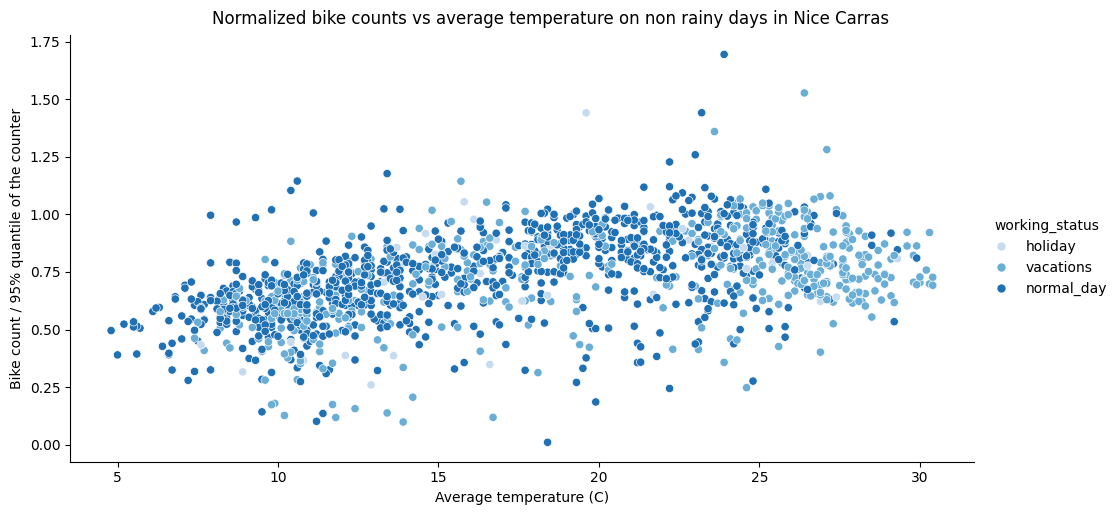

In [63]:
lm_graph = sns.relplot(
    data=plot_data.query("prcp == 0 and counter == 'nice_carras'"),
    x="tavg",
    y="normalized_count",
    hue="working_status",
    aspect=2,
    palette="Blues",
)
lm_graph.figure.suptitle("Normalized bike counts vs average temperature on non rainy days in Nice Carras", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

Rather than graphs, one may prefer to look at statistics.
Below, the tables summarize the basic statistics in Nice for mild or hot days.

In [64]:
print("Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 18 and tavg < 23").loc[:,["normalized_count", "tavg"]].dropna().describe()

Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras:


,normalized_count,tavg
count,272.000000,272.0
mean,0.825238,20.382721
std,0.178262,1.435873
min,0.010275,18.1
25%,0.753783,19.175
50%,0.859105,20.3
75%,0.933434,21.6
max,1.440554,22.9


In [65]:
print("Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 23").loc[:,["normalized_count", "tavg"]].dropna().describe()

Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras:


,normalized_count,tavg
count,395.000000,395.0
mean,0.815942,25.829367
std,0.164961,1.829565
min,0.247724,23.1
25%,0.716703,24.3
50%,0.819344,25.6
75%,0.917630,27.1
max,1.694309,30.4


Looking at the median (more robust to the yet unfiltered outliers), counts could look lower at high temperatures.
But is this explained by a true effect of the temperature or just by the working status confounding factor ? 

The tables below recompute these statistics, separated by working day status category :

In [66]:
print("Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras, depending on working status:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 18 and tavg < 23").groupby("working_status", observed=True)[["normalized_count", "tavg"]].describe()

Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras, depending on working status:


normalized_count                                          \
                          count      mean       std       min       25%   
working_status                                                            
holiday                     8.0  0.933881  0.250458  0.648238  0.811024   
vacations                  41.0  0.748992  0.164393  0.312727  0.684872   
normal_day                223.0  0.835358  0.174190  0.010275  0.781147   

                                               tavg                       \
                     50%       75%       max  count       mean       std   
working_status                                                             
holiday         0.913944  1.012174  1.440554    8.0      20.55  1.822087   
vacations       0.776456  0.883677  0.959625   41.0  20.173171  1.651972   
normal_day      0.868040  0.945999  1.227453  223.0  20.415247  1.382106   

                                                  
                 min     25%   50%     75%   max  
working_status                                    
holiday         18.4  19.025  20.6  21.925  22.8  
vacations       18.1    18.7  19.8    22.0  22.9  
normal_day      18.1    19.2  20.4   21.45  22.9

In [67]:
print("Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras, depending on working status:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 23").groupby("working_status", observed=True)[["normalized_count", "tavg"]].describe()

Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras, depending on working status:


normalized_count                                          \
                          count      mean       std       min       25%   
working_status                                                            
holiday                    10.0  0.776411  0.082571  0.622326  0.767298   
vacations                 234.0  0.804287  0.159916  0.247724  0.701513   
normal_day                151.0  0.836620  0.174924  0.276093  0.761267   

                                               tavg                       \
                     50%       75%       max  count       mean       std   
working_status                                                             
holiday         0.798012  0.825040  0.860892   10.0      25.78  1.895492   
vacations       0.797118  0.913051  1.527001  235.0      26.48  1.756716   
normal_day      0.846150  0.938404  1.694309  151.0  24.803311  1.442887   

                                                 
                 min     25%    50%   75%   max  
working_status                                   
holiday         23.2  24.525  25.95  26.8  29.3  
vacations       23.1    25.2   26.4  27.7  30.4  
normal_day      23.1   23.65   24.4  25.6  29.9

Letting aside once again the average which it too sensitive to unfiltered outliers, the median values can be compared once again

While the counts look sensibly lower on vacation days than normal ones _and_ that vacation days are much more represented at higher temperatures, this could explain part of the decay in the graphs above.
Yet, for all day categories, bike counts still seem a bit lower at higher temperatures.

This provides evidences in favour of a more thourough investigation of the combined effect of calendar and temperature on the bicycle counts.

# Deciding how to model the temperature

The previous section illustrated that the bicycle count seem to increase linearly with temperature, but that, after a certain threshold, this increase looks to stall, or even turn into a decay.
Yet, the graphs and statistics also rose the question whether this change of regime actually happend, or could just be the effect of other confounding factors, such as vacations, holidays or other simple calendar effects.

This section tries to answer this question by a more quantitative yet still intentionally simple analysis. 

First of all **H0 : The bicyle count is assumed to change linearly with temperature, as it increases from the coldest to mildest values**.

Then, two assumptions are considered : 
- **H1**: the bike count increases linarly with temperature with constant thermosensitivity.
- **H2**: the bike count sensitivity to temperature changes after a certain temperature threshold.

While more complex relations could be considered, this seems to be a good starting point for this analysis.
In case H2 is favoured after this investigation, more complex models may be introduced if they appear relevant.

As a first step, only days when no rain was recored are considered in the analysis, to focus on the effect of temperature only.
A segmented regression model with two regimes is introduced to represent the temperature, and the plausibility of a shift in the thermosenitivity is studied. 

Then, the effect of rain is introduced to complete the analysis.


## High-temperature effect with segmented regression
In order to assess whether bike counts start decreasing above a temperature threshold, while controlling for calendar effects, a segmented regression model is tested, similar to what is done in building energy consumption analysis.

Energy building consumption typically uses three segementations, with an assumed constant value between the heating and cooling threshold temperatures. While these thresholds are not known in advance and have to be determined, ad-hoc values adapted to different locations in the country are now widely available as good starting points.


As this is not true for bicyle counts analysis, a simpler model, with less degrees of freedom is used to begin with : _the bike count is assumed to be affine by parts, with one slope value under a certain temperature threshold and another one above the threhsold._
The main idea under this choice, is that a significant difference of slope below and above threshold, would be an evidence that a more complex model that plain linear regression is required.

This section evaluates how plausible this model is and whether or not it seems better suited than a plain affine regression. 
In order to focus on the effect of temperature, _only non-rainy days are considered in this section_.

### Segmented regression model specification

For each counter, the following piecewise linear model is fitted:
$$
\text{normalized\_count}_t = \beta_0 + \beta_1 T_t + \beta_2 (T_t-c)_+ + \gamma^\top X_t + \varepsilon_t
$$
with:
- $T_t$: average daily temperature (`tavg`),
- $(T_t-c)_+ = \max(T_t-c,0)$: hinge term beyond threshold $c$,
- $X_t$: controls (`working_status`, `day_name`, `month`).

In this model :
- $c$ is the temperature threshold above which the thermosensitivity of bike counts is assumned to change,
- $\beta_1$ is the bike count thermosensitivity below the temperature threshold,
- $\beta_1 + \beta_2$ is the bike count thermosensitivity above the temperature threshold.

As data along the whole year is used, and calendar-related features have shown to have an effect on the count values, the effect of working status, day name and month must also be included in the model, which requires to think about the expected relation of the counts and these variables.

**Important note** :
The model above assumes that depending on the these features, _a certain number_ of cyclists chose to cycle or not, regardless of other factors such as temperature.
However, other kinds of effects are actually more plausible such as _a certain proportion_ of cyclists chose to cycle or not depending on these features, which would require another from of model. E.g. effects of different parameters or combinations of parameters could be modelled by multiplicative combination instead of additive one, in which case one could work on the log of the count values to come back to an additive model.

*In order to keep it simple, a linear effect of the calendar-related feature is used. High heteroscedasticity of the residuals coudld be a clue that this model is not suited.*


If the suspected decrease at higher temperatures is just an effect of vacations and/or calendar, it may be captured by this term.
Conversely, a value of $\beta_2 < 0$ and significant, would support a heat-related decrease above $c$.

_Note_ : The data contains sampled collected on different years, while the cycling culture and infrastructure have evolved a lot, especially in Paris.
If the study were to be continued more thoroughly, this variable could be used in the model as well.

### Segmented regression data preparation
To begin with, only non rainy days are considered to ease the investigation of the effect of temperature.

In [68]:
# Step 1.1 - Build an analysis dataset for the segmented regression
cols_needed = [
    "counter", "normalized_count", "tavg", "prcp",
    "working_status", "day_name", "date"
 ]

step1_data = (
    plot_data.loc[:, cols_needed]
    .dropna(subset=["normalized_count", "tavg", "working_status", "day_name", "date"])
    .copy()
 )

# Focus on non-rainy days to isolate the thermal signal
step1_data = step1_data.loc[step1_data["prcp"] == 0].copy()
step1_data["month"] = pd.to_datetime(step1_data["date"]).dt.month.astype(str)

print("Rows retained:", len(step1_data))
print("Counters:", sorted(step1_data["counter"].unique()))
step1_data[["counter", "normalized_count", "tavg", "working_status", "day_name", "month"]].head()

Rows retained: 3605
Counters: ['cagnes_sur_mer', 'nice_carras', 'paris_sebastopol']


,counter,normalized_count,tavg,working_status,day_name,month
2,paris_sebastopol,0.206009,2.2,vacations,Saturday,1
4,paris_sebastopol,0.170822,3.4,vacations,Sunday,1
6,paris_sebastopol,0.334358,3.1,normal_day,Monday,1
8,paris_sebastopol,0.387010,3.1,normal_day,Tuesday,1
10,nice_carras,0.505947,5.7,normal_day,Wednesday,1


### Segmented regression threshold selection
In the segmented model, $c$ is the temperature at which the slope may change.
This value is not known a priori and cannot be fixed reliably from visual inspection only.
If $c$ is misspecified, the model may either miss a true high-temperature decrease or introduce an artificial break-point.

For each counter, the model is therfore fitted on a grid of candidate thresholds. 
Candidates are then compared with the [Akaike Information Criterion (AIC)](https://en.wikipedia.org/wiki/Akaike_information_criterion), which balances two objectives:
- quality of fit (likelihood / residual error),
- parsimony (penalty for unnecessary complexity).

Even when candidate models share the same structure, AIC provides a principled and consistent criterion to select the threshold that best explains the data.
Accordingly, for each counter, the best candidate according to this metric is retained.

This is done thanks to the following utility function :

In [69]:
# Step 1.2 - Search the best threshold c (AIC criterion) for each counter
def fit_piecewise_for_counter(data, counter_name, c_grid=None, tmin=5, tmax=40):
    """Fit segmented temperature model and select threshold by AIC.

    Parameters
    ----------
    data : pandas.DataFrame
        Daily observations for one or several counters. Required columns are:
        ``counter`` (str), ``normalized_count`` (dimensionless), ``tavg``
        (degree Celsius), ``working_status`` (categorical), ``day_name``
        (categorical), and ``month`` (categorical).
        Sampling scheme: each row corresponds to one civil day and stores daily
        aggregated values for that day.
    counter_name : str
        Counter identifier used to subset ``data``.
    c_grid : array-like of float, optional
        Candidate threshold temperatures (degree Celsius). If ``None``, a
        data-driven grid is built from the observed ``tavg`` range with a
        0.5 degree Celsius step.
    tmin : float, optional
        Minimum temperature for the grid (degree Celsius). Default is 5.
    tmax : float, optional
        Maximum temperature for the grid (degree Celsius). Default is 40.

    Returns
    -------
    dict
        Dictionary with keys:
        - ``counter`` : str
            Counter name used for fitting.
        - ``best_threshold`` : float
            AIC-optimal threshold temperature (degree Celsius).
        - ``best_aic`` : float
            AIC value of the selected model.
        - ``model`` : statsmodels.regression.linear_model.RegressionResultsWrapper
            Fitted OLS model at the selected threshold (HC3 covariance).
        - ``aic_profile`` : pandas.DataFrame
            Table with columns ``threshold`` and ``aic`` for all tested
            candidates.
        - ``n`` : int
            Number of daily samples used for this counter.
        - ``threshold_at_grid_edge`` : bool
            True if the selected threshold is at the min or max of tested valid
            (model fit converged) grid values.

    Notes
    -----
    Model form is:
    ``normalized_count ~ tavg + max(tavg - c, 0) + C(working_status) +``
    ``C(day_name) + C(month)``.

    The threshold ``c`` is unknown and is selected by minimizing AIC over the
    candidate grid. The objective is to identify a slope change temperature
    while controlling for calendar composition.

    AIC-based selection supports model comparison between candidate thresholds
    using a consistent fit-versus-complexity criterion in this exploratory
    context.

    Raises
    ------
    ValueError
        If no candidate model can be fitted for the selected counter.
    """
    subset = data.loc[data["counter"] == counter_name].copy()
    if c_grid is None:
        # Use a broad, data-driven grid to avoid boundary artifacts
        tmin = max(float(np.floor(subset["tavg"].min() + 0.5)), tmin)
        tmax = min(float(np.ceil(subset["tavg"].max() - 0.5)), tmax)
        c_grid = np.arange(tmin, tmax + 0.001, 0.5)
    scores = []
    for c in c_grid:
        tmp = subset.copy()
        tmp["tavg_hinge"] = np.maximum(tmp["tavg"] - c, 0)
        formula = "normalized_count ~ tavg + tavg_hinge + C(working_status) + C(day_name) + C(month)"
        try:
            model = smf.ols(formula=formula, data=tmp).fit(cov_type="HC3")
            scores.append((c, model.aic, model))
        except Exception:
            continue
    if not scores:
        raise ValueError(f"No model could be fitted for {counter_name}")
    best_c, best_aic, best_model = min(scores, key=lambda x: x[1])
    score_df = pd.DataFrame(scores, columns=["threshold", "aic", "model"]).drop(columns="model")
    edge_flag = (best_c == score_df["threshold"].min()) or (best_c == score_df["threshold"].max())
    return {
        "counter": counter_name,
        "best_threshold": best_c,
        "best_aic": best_aic,
        "model": best_model,
        "aic_profile": score_df,
        "n": len(subset),
        "threshold_at_grid_edge": edge_flag,
    }

Here is a raw result of the application of this gridsearch of the threshold temperature as an AIC vs threshold temperature plot and result table: 

In [70]:
step1_results = {counter_name: fit_piecewise_for_counter(step1_data, counter_name) for counter_name in bike_counters}

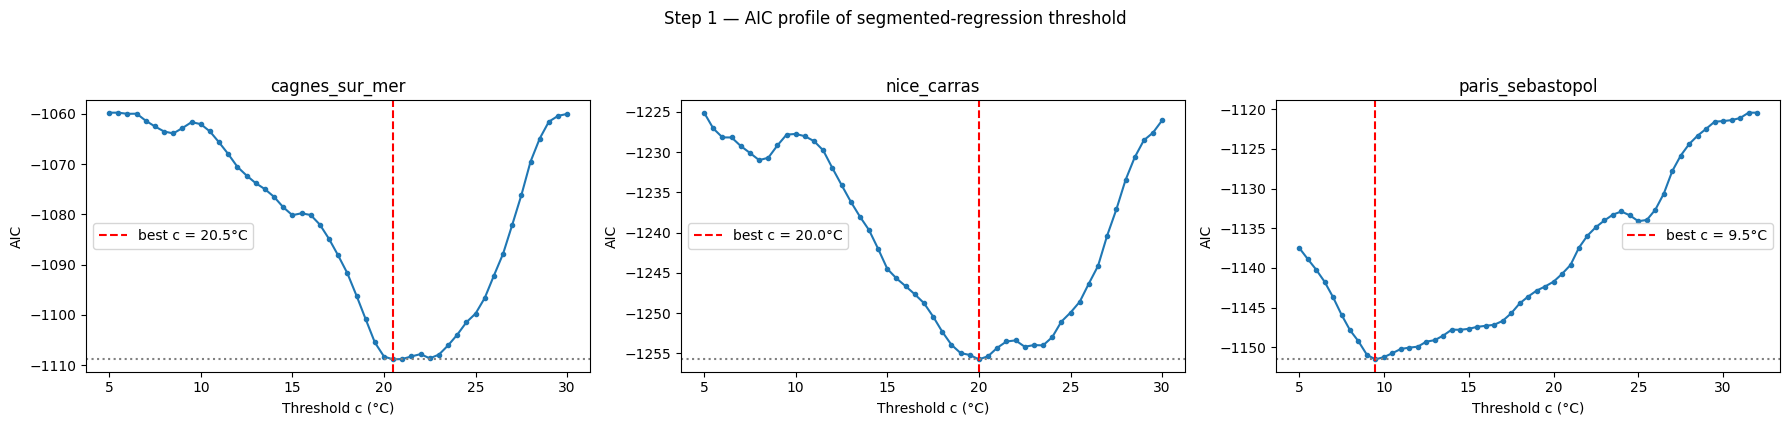

,counter,best_threshold,best_aic,n,threshold_at_grid_edge
0,cagnes_sur_mer,20.5,-1108.865804,1234,False
1,nice_carras,20.0,-1255.754215,1420,False
2,paris_sebastopol,9.5,-1151.523706,951,False


In [71]:
# Plot AIC profile to assess threshold identifiability
n_counters = len(step1_results)
fig, axes = plt.subplots(1, n_counters, figsize=(6 * n_counters, 4), sharey=False)

if n_counters == 1:
    axes = [axes]

for ax, counter_name in zip(axes, sorted(step1_results.keys())):
    prof = step1_results[counter_name]["aic_profile"].sort_values("threshold")
    best_c = step1_results[counter_name]["best_threshold"]
    best_aic = step1_results[counter_name]["best_aic"]
    ax.plot(prof["threshold"], prof["aic"], marker="o", ms=3)
    ax.axvline(best_c, color="red", linestyle="--", label=f"best c = {best_c:.1f}°C")
    ax.axhline(best_aic, color="gray", linestyle=":")
    ax.set_title(counter_name)
    ax.set_xlabel("Threshold c (°C)")
    ax.set_ylabel("AIC")
    ax.legend()

plt.suptitle("Step 1 — AIC profile of segmented-regression threshold", y=1.05)
plt.tight_layout()
plt.show()

# Simple summary table
step_1_raw = pd.DataFrame({
    "counter": list(step1_results.keys()),
    "best_threshold": [v["best_threshold"] for v in step1_results.values()],
    "best_aic": [v["best_aic"] for v in step1_results.values()],
    "n": [v["n"] for v in step1_results.values()],
    "threshold_at_grid_edge": [v["threshold_at_grid_edge"] for v in step1_results.values()],
}).sort_values("counter")

step_1_raw

While the values for South-Eastern France are in the expected range and look consistent with the assumed model, the value for Paris is more surprising. 

Also, a glich/second local minimum in the AIC plot for low values can be seen for Paris. It might come from numerical difficulties due to the low number of samples at low temperature, or indicate that a simple affine regression is best suited there (in case the threshold would be about the min temperature).

Let plot the model and observed values for each sample :

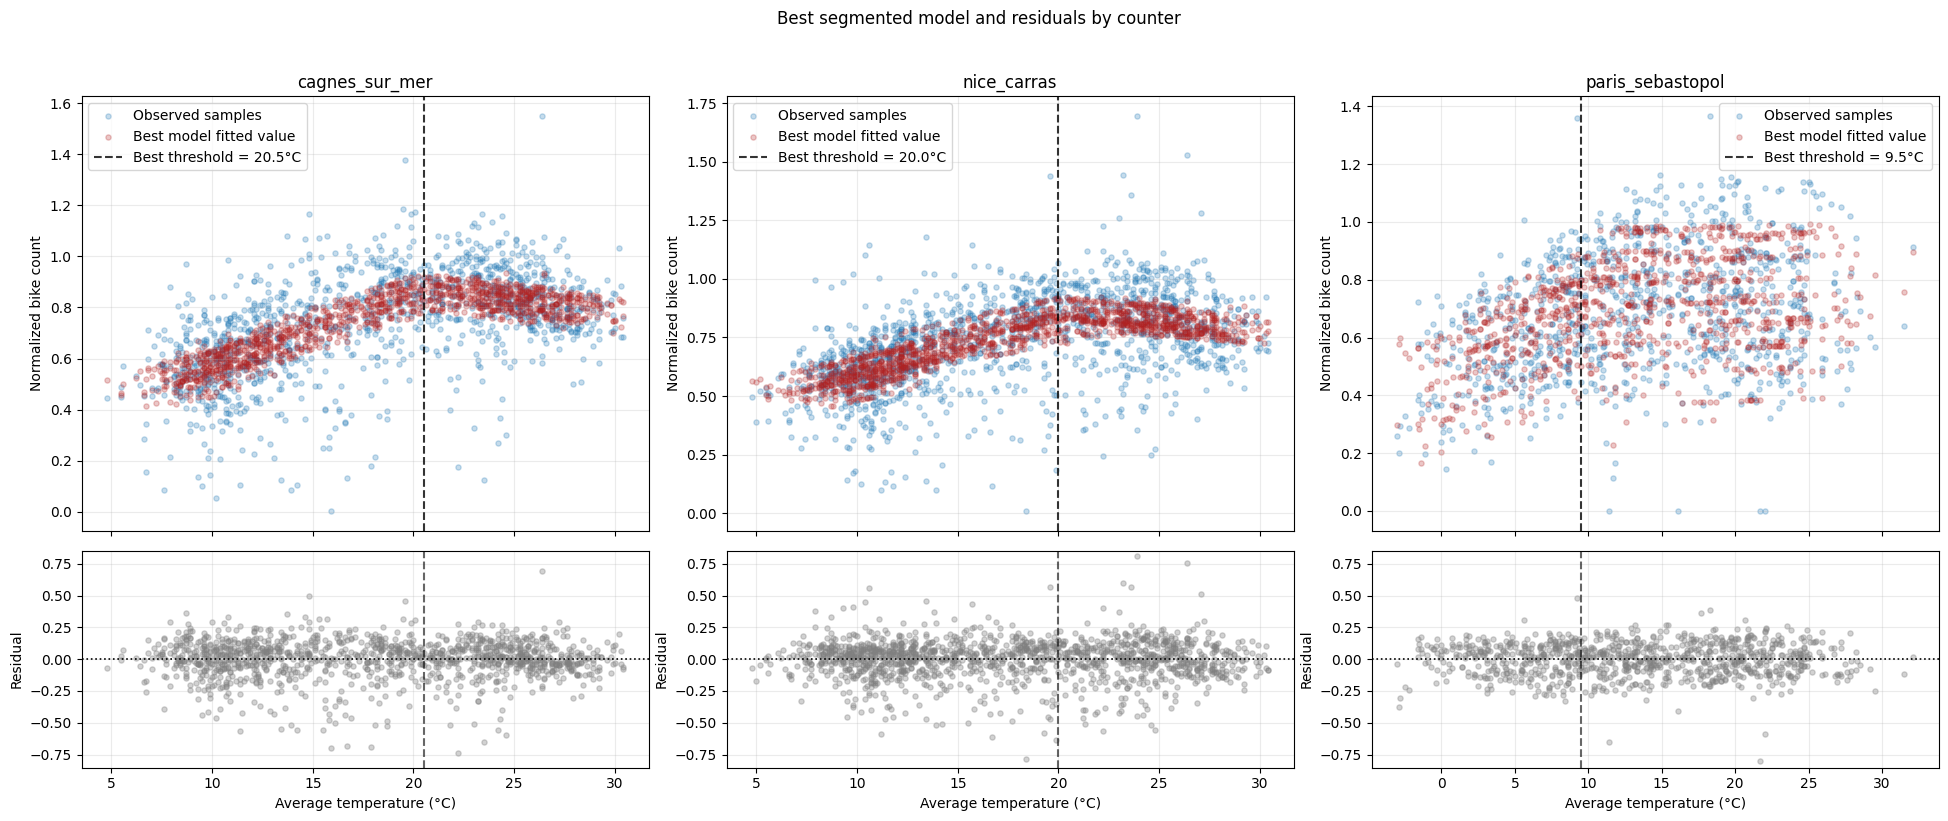

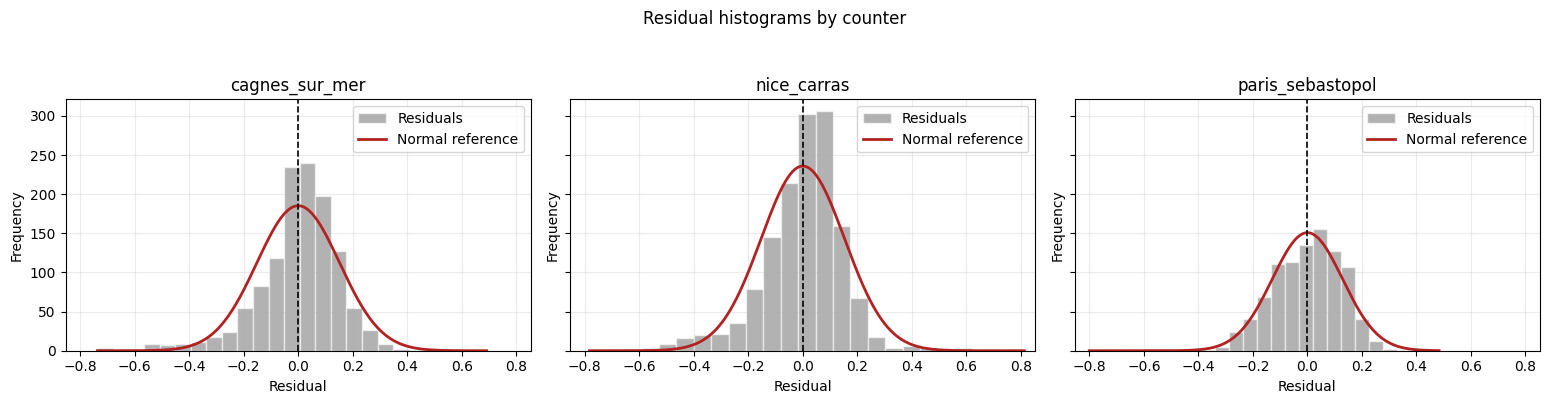

In [72]:
# Plot best segmented model fit vs observed samples for each counter
counter_list = sorted(step1_results.keys())

# Common residual scale to compare counters directly
residual_abs_max = max(
    np.nanmax(np.abs(step1_results[counter_name]["model"].resid))
    for counter_name in counter_list
)
resid_lim = 1.05 * residual_abs_max

fig, axes = plt.subplots(
    2,
    len(counter_list),
    figsize=(6.5 * len(counter_list), 8),
    sharex="col",
    squeeze=False,
    gridspec_kw={"height_ratios": [3, 1.5]}
)

for idx, counter_name in enumerate(counter_list):
    ax_model = axes[0, idx]
    ax_resid = axes[1, idx]

    subset = step1_data.loc[step1_data["counter"] == counter_name].copy()
    best_model = step1_results[counter_name]["model"]
    best_c = step1_results[counter_name]["best_threshold"]

    # Fitted values and residuals for each original sample
    fitted_vals = best_model.fittedvalues
    residuals = best_model.resid
    subset = subset.assign(fitted=fitted_vals, residual=residuals)
    subset_sorted = subset.sort_values("tavg")

    # Top row: observed vs fitted values
    ax_model.scatter(
        subset["tavg"],
        subset["normalized_count"],
        s=14,
        alpha=0.25,
        label="Observed samples",
    )
    ax_model.scatter(
        subset_sorted["tavg"],
        subset_sorted["fitted"],
        color="firebrick",
        s=14,
        alpha=0.25,
        label="Best model fitted value",
    )
    ax_model.axvline(
        best_c,
        color="black",
        linestyle="--",
        alpha=0.8,
        label=f"Best threshold = {best_c:.1f}°C",
    )
    ax_model.set_title(counter_name)
    ax_model.set_ylabel("Normalized bike count")
    ax_model.legend()
    ax_model.grid(alpha=0.25)

    # Bottom row: residuals below model plot
    ax_resid.scatter(
        subset["tavg"],
        subset["residual"],
        s=14,
        alpha=0.35,
        color="gray",
    )
    ax_resid.axhline(0, color="black", linestyle=":", linewidth=1.2)
    ax_resid.axvline(best_c, color="black", linestyle="--", alpha=0.6)
    ax_resid.set_ylim(-resid_lim, resid_lim)
    ax_resid.set_xlabel("Average temperature (°C)")
    ax_resid.set_ylabel("Residual")
    ax_resid.grid(alpha=0.25)

plt.suptitle("Best segmented model and residuals by counter", y=1.02)
plt.tight_layout()
plt.show()

# Separate residual histograms (one per counter)
fig_hist, axes_hist = plt.subplots(
    1,
    len(counter_list),
    figsize=(5.2 * len(counter_list), 3.8),
    sharey=True,
    squeeze=False,
    )
axes_hist = axes_hist[0]

for idx, counter_name in enumerate(counter_list):
    ax = axes_hist[idx]
    residuals = step1_results[counter_name]["model"].resid

    hist_counts, bin_edges, _ = ax.hist(
        residuals,
        bins=25,
        color="gray",
        alpha=0.6,
        edgecolor="white",
        label="Residuals",
    )

    mu = float(np.mean(residuals))
    sigma = float(np.std(residuals, ddof=1))
    if sigma > 0:
        x_grid = np.linspace(bin_edges[0], bin_edges[-1], 300)
        bin_width = float(bin_edges[1] - bin_edges[0])
        y_norm = scipy.stats.norm.pdf(x_grid, loc=mu, scale=sigma) * len(residuals) * bin_width
        ax.plot(x_grid, y_norm, color="firebrick", linewidth=2, label="Normal reference")

    ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax.set_xlim(-resid_lim, resid_lim)
    ax.set_title(counter_name)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.25)
    ax.legend()

plt.suptitle("Residual histograms by counter", y=1.05)
plt.tight_layout()
plt.show()

From these graphs, the following can be observed : 
* As samples have various calendar and working status, modelled values show an expected spread around the affine trend.
* In the case of Paris, the vertical spread is very high compared with other locations. This makes the graph shape less obvious, but is consistent with a stronger effect of day of week and working status.
* The residuals distribution looks correct for all models, especially when one considers that this analysis is done on an a rather raw dataset which wasn't cured from manifest outliers. 
    * In particular, when looking for a model which describes the averaged effect of exogeneous parameters as done above, the data from SE France could be cleaned by removing many of the days with abnormally low counts. They result of the effect of other irrelevant exogeneous effects such as counter malfunction and special events such as races which lead to a road closure most of the day. 


### Segmented regression decision metrics

The previous table provided the best threshold $c$ per counter (minimum AIC).
Now interpretable quantities can be extracted from the selected model, in particular:
- slope below threshold ($\beta_1$),
- slope above threshold ($\beta_1 + \beta_2$),
- slope change ($\beta_2$), with confidence intervals and p-values.

In [73]:
# Step 1.4 - Extract coefficients and statistics from fitted models
step1_summary = []
for counter_name in sorted(step1_results.keys()):
    result = step1_results[counter_name]
    model = result["model"]
    best_c = result["best_threshold"]

    # Extract coefficients
    slope_below = model.params["tavg"]
    slope_change = model.params["tavg_hinge"]
    slope_above = slope_below + slope_change

    # Extract confidence intervals and p-values
    ci = model.conf_int(alpha=0.05)
    slope_below_ci_low = ci.loc["tavg", 0]
    slope_below_ci_high = ci.loc["tavg", 1]
    slope_change_ci_low = ci.loc["tavg_hinge", 0]
    slope_change_ci_high = ci.loc["tavg_hinge", 1]
    slope_above_ci_low = slope_below_ci_low + slope_change_ci_low
    slope_above_ci_high = slope_below_ci_high + slope_change_ci_high
    slope_change_pvalue = model.pvalues["tavg_hinge"]

    step1_summary.append({
        "counter": counter_name,
        "best_threshold_C": best_c,
        "n_samples": result["n"],
        "r2": model.rsquared,
        "slope_below": slope_below,
        "slope_below_ci_low": slope_below_ci_low,
        "slope_below_ci_high": slope_below_ci_high,
        "slope_above": slope_above,
        "slope_above_ci_low": slope_above_ci_low,
        "slope_above_ci_high": slope_above_ci_high,
        "slope_change_above_threshold": slope_change,
        "slope_change_ci_low": slope_change_ci_low,
        "slope_change_ci_high": slope_change_ci_high,
        "slope_change_pvalue": slope_change_pvalue,
    })

step1_summary = pd.DataFrame(step1_summary)
step1_summary

,counter,best_threshold_C,n_samples,r2,slope_below,slope_below_ci_low,slope_below_ci_high,slope_above,slope_above_ci_low,slope_above_ci_high,slope_change_above_threshold,slope_change_ci_low,slope_change_ci_high,slope_change_pvalue
0,cagnes_sur_mer,20.5,1234,0.396832,0.022510,0.015335,0.029684,-0.011674,-0.028398,0.005051,-0.034183,-0.043734,-0.024633,2.300167e-12
1,nice_carras,20.0,1420,0.345808,0.018322,0.012849,0.023794,-0.006709,-0.020893,0.007474,-0.025031,-0.033743,-0.016320,1.785077e-08
2,paris_sebastopol,9.5,951,0.631972,0.018654,0.013606,0.023701,0.001835,-0.009420,0.013090,-0.016819,-0.023026,-0.010611,1.093754e-07


The p-values and confidence intervals reported above are valid under the following assumptions (or close approximations):

- **Correct mean specification (conditional model)**: after including `tavg`, `tavg_hinge`, `working_status`, `day_name`, and `month`, the conditional mean structure is reasonably well specified.
- **Exogeneity / no major omitted confounders**: residual shocks should not be systematically correlated with included regressors (in particular with temperature and hinge terms).
- **Independent observations (or weak enough dependence)**: HC3 robust covariance protects against heteroskedasticity, but it does not fully correct serial autocorrelation in daily time series.
- **Sufficient sample size**: inference is asymptotic; with many daily observations this is usually acceptable, but small effective sample size from temporal dependence can reduce reliability.

These assumptions seem reasonable enough in the context of this section, which just aims at deciding whether an inflexion of the bike count at high temperature is plausible or not.
Deciding the right model and fine-tuning the choice of input features will be the subject of future work.

_Note : In particular, regarding observation independance, the assumption is likely a bit loose. While part of the serial autocorrelation in the data is likely explainable by the weather and calendar, accounted for in the model, part of it is expected to remain. The effect of change in the bike culture and bike infrastructure, in particular in Paris, should likely introduce a temporal trend which was not accouted for by the model which mixes data collected from 2021 to 2026._

Also, the uncertainty about the actual value of the temperature threshold, assuming the model is correct, is not accounted for in the inference metrics computation (this study isn't pushed up to a nice and clean bayesian UQ), which should be kept in mind when interpreting the values.

### Additional insights of segmented regression

While thermosensitivity coefficient values only were discussed below, interesting insight can be found from a quick look at other coefficients in the models.

See the summary of the model for Nice and Paris below : 

In [74]:
step1_results['nice_carras']['model'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       normalized_count   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     45.62
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          7.21e-142
Time:                        07:52:00   Log-Likelihood:                 649.88
No. Observations:                1420   AIC:                            -1256.
Df Residuals:                    1398   BIC:                            -1140.
Df Model:                          21                                         
Covariance Type:                  HC3                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.3797      0.039      9.746      0.000       0.303       0.456
C(working_status)[T.vacations]     -0.0112      0.030     -0.375      0.707      -0.070       0.047
C(working_status)[T.normal_day]     0.0286      0.029      0.971      0.331      -0.029       0.086
C(day_name)[T.Tuesday]              0.0696      0.014      5.026      0.000       0.042       0.097
C(day_name)[T.Wednesday]            0.0301      0.015      2.038      0.042       0.001       0.059
C(day_name)[T.Thursday]             0.0610      0.015      3.970      0.000       0.031       0.091
C(day_name)[T.Friday]              -0.0101      0.014     -0.721      0.471      -0.038       0.017
C(day_name)[T.Saturday]            -0.0212      0.013     -1.593      0.111      -0.047       0.005
C(day_name)[T.Sunday]              -0.0196      0.016     -1.204      0.229      -0.052       0.012
C(month)[T.10]                      0.0174      0.034      0.510      0.610      -0.050       0.084
C(month)[T.11]                      0.0239      0.023      1.044      0.296      -0.021       0.069
C(month)[T.12]                     -0.0491      0.016     -3.074      0.002      -0.080      -0.018
C(month)[T.2]                       0.0072      0.018      0.399      0.690      -0.028       0.043
C(month)[T.3]                       0.0065      0.022      0.304      0.761      -0.036       0.049
C(month)[T.4]                       0.0720      0.026      2.817      0.005       0.022       0.122
C(month)[T.5]                       0.0748      0.033      2.269      0.023       0.010       0.139
C(month)[T.6]                       0.0795      0.035      2.285      0.022       0.011       0.148
C(month)[T.7]                       0.1030      0.042      2.459      0.014       0.021       0.185
C(month)[T.8]                       0.0808      0.042      1.936      0.053      -0.001       0.163
C(month)[T.9]                       0.0721      0.037      1.955      0.051      -0.000       0.144
tavg                                0.0183      0.003      6.562      0.000       0.013       0.024
tavg_hinge                         -0.0250      0.004     -5.632      0.000      -0.034      -0.016
==============================================================================
Omnibus:                      176.700   Durbin-Watson:                   1.297
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              685.403
Skew:                          -0.554   Prob(JB):                    1.47e-149
Kurtosis:                       6.218   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [75]:
step1_results['paris_sebastopol']['model'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       normalized_count   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     90.03
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          5.23e-207
Time:                        07:52:00   Log-Likelihood:                 597.76
No. Observations:                 951   AIC:                            -1152.
Df Residuals:                     929   BIC:                            -1045.
Df Model:                          21                                         
Covariance Type:                  HC3                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.2198      0.030      7.303      0.000       0.161       0.279
C(working_status)[T.vacations]      0.1578      0.026      6.079      0.000       0.107       0.209
C(working_status)[T.normal_day]     0.2947      0.025     11.986      0.000       0.247       0.343
C(day_name)[T.Tuesday]              0.0792      0.015      5.352      0.000       0.050       0.108
C(day_name)[T.Wednesday]            0.0657      0.016      4.113      0.000       0.034       0.097
C(day_name)[T.Thursday]             0.0839      0.017      5.054      0.000       0.051       0.116
C(day_name)[T.Friday]               0.0016      0.016      0.099      0.921      -0.030       0.033
C(day_name)[T.Saturday]            -0.0753      0.014     -5.233      0.000      -0.103      -0.047
C(day_name)[T.Sunday]              -0.1839      0.013    -14.207      0.000      -0.209      -0.159
C(month)[T.10]                      0.1996      0.026      7.749      0.000       0.149       0.250
C(month)[T.11]                      0.1061      0.023      4.673      0.000       0.062       0.151
C(month)[T.12]                      0.0103      0.020      0.505      0.614      -0.030       0.050
C(month)[T.2]                       0.0527      0.022      2.451      0.014       0.011       0.095
C(month)[T.3]                       0.0316      0.023      1.355      0.176      -0.014       0.077
C(month)[T.4]                       0.0234      0.028      0.845      0.398      -0.031       0.078
C(month)[T.5]                       0.0899      0.026      3.492      0.000       0.039       0.140
C(month)[T.6]                       0.1624      0.029      5.590      0.000       0.105       0.219
C(month)[T.7]                       0.0848      0.036      2.365      0.018       0.015       0.155
C(month)[T.8]                      -0.0092      0.033     -0.278      0.781      -0.074       0.055
C(month)[T.9]                       0.1897      0.028      6.776      0.000       0.135       0.245
tavg                                0.0187      0.003      7.244      0.000       0.014       0.024
tavg_hinge                         -0.0168      0.003     -5.310      0.000      -0.023      -0.011
==============================================================================
Omnibus:                       96.133   Durbin-Watson:                   0.522
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              220.199
Skew:                          -0.582   Prob(JB):                     1.53e-48
Kurtosis:                       5.050   Cond. No.                         282.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

While the residual metrics indicate that the OLS model assumptions are not fully satisfied (e.g. Durbin-Watson indicates an autocorrelation, and other metrics indicate heavier tails than normal distribution, as already discussed), the analysis of the coefficients and their associated statistics complement the plots that were done in the previous sections to get an insight of the effect of other parameters.

Detailed analysis is out of the scope here but could be interesting on a future, better fitted model.

### Conclusion about segmented regression 

The segmented-regression test provides evidence that thermosensitivity changes above a threshold in all three counters (negative and significant hinge coefficient $\beta_2$).

For non-rainy days, controlling for `working_status`, `day_name` and `month` with a simple linear addidtive effect :
- **Cagnes-sur-Mer**: best threshold around **20.5°C**. Estimated slope changes from about **+0.0225** below threshold to **-0.0117** above threshold. This supports a real high-temperature decline.
- **Nice Carras**: best threshold around **20.0°C**. Estimated slope changes from about **+0.0183** below threshold to **-0.0067** above threshold. This also supports a high-temperature decline.
- **Paris Sebastopol**: best threshold around **9.5°C**. The slope change is negative _and significant_, but the high-temperature slope remains close to zero/slightly positive (**+0.0018**, CI crossing 0). So this test does not support a clear drop in Paris at high temperatures, but rather a flattening, right from the moment the temperature becomes "not too cold". Recalling the comparison with energy consumption at [the beginning of this section](#high-temperature-effect-with-segmented-regression), this could just be be a limit of this simple one-threshold affine model.

Overall the collected evidence are consistent with the following assumptions about bike counts evolution :
1. On the French Riviera counters, results are consistent with the hypothesis 
   * the number of cyclists increses with temperature up to ~20°C;
   * “beyond ~20°C, higher temperature leads to fewer cyclists.
2. In Paris Sebastopol :
   * the number of cyclists increses with temperature up to ~10°C;
   * beyond this threshold, the number of cyclists more or less stops increasing with temperature. 

Of course many more steps would need to be added to improve the analysis in order to get a trustworthy model : data cleaning, AIC comparison with plain linear model, investigation of the potential effects of interaction, maybe restricting to different years, accounting for samples temporal correlation  etc.

All this is saved for later work, with more application focused models. 

## Including the effect of rain

In the previous investigation about the effect of temperature, the effect of rain on the count of cyclists was not considered by working on non-rainy days only. 
Yet, as could be guessed from the plots in the [first visual exploration of the effect of weather](#investigating-the-effect-of-weather), the counts of cyclists seem to drop on rainy days VS sunny ones. 

Accordingly, this section investigates how rain affects the counts of cyclists, besides the effect of temperature identified above. 
As discussed for other exogeneous parameters, the effect of rain could be be of different natures : 
* a certain _propotion_ of the road users could chose to cycle or not depending on the rain;
* a certain _number_ of them could chose to cycle or not depending on the rain;
* rain could affect the slope of the thermosensitivity and/or the temeprature threshold;
* all this could depend or not on the other exogeneous parameters, e.g. more cyclists could keep riding on working days than vacation days;
* all this could depend on the _amount_ of rain (value of `prcp` as a continuous variable) or just on the _fact_ that it rains or not (rain as a categorical variable).

Following an idea that the simpler, the better : 
* this study starts by investigating the effect of rain as a simple additive factor besides others;
* interactions with temperature and hinge temperature are considered to look for an effect of rain on the thermosensitivity;

Some features are left aside on purpose for the sake of simplicity : 
* More complex interactions aren't considered for now, enabling e.g. to adapt the thermosensitivity for different rain and working days to not.
* An adaptation of the temperature threshold depening on the rain is also not considered.

Future work, which could combine data from different counters in the same area could be used to push this investigation further if deemed necessary.

For now, this section investigates the effect of rain in the following way : 
* First the dataset is reprepared to include the rainy days in the model fitting data. This is also the opportunity to look a bit more in detail at the amount of data it contains about rainy conditions.
* Then a ladder of models is fitted, that include rain as a _continuous variable_ and its interactions with temperature and hinge temperature in a progressive way.
* Finally, a model including rain as a _categorical variable_ is also tested on the best performing formulation.


### Preparing the rain-analysis dataset

Before looking at rain-temperature interactions, we first need a clean and consistent dataset at counter level.
So the idea here is simple: keep only the variables needed for the model ladder, check missing values, and get a first picture of rain distribution.

No interaction model is fitted yet in this part.

The dataset below is built from the exploration table, keeping the selected counters and the variables needed for modeling (`normalized_count`, `tavg`, `prcp`, `working_status`, `day_name`, `month`).
Then a complete-case sample is defined so that nested models can be compared on the same observations.

The same cell also builds two quick diagnostics: one for missingness/sample retention, and one for rain distribution by counter.

In [ ]:
# Step R1 - Build analysis dataset and QC checks (per counter)
import numpy as np
import pandas as pd

# Start from the exploration dataset used in previous sections
rain_step1_raw = plot_data.copy()

# Harmonize control column names expected in the modeling formulas
if "month" not in rain_step1_raw.columns:
    if "month_name" in rain_step1_raw.columns:
        rain_step1_raw["month"] = rain_step1_raw["month_name"]
    elif "date" in rain_step1_raw.columns:
        rain_step1_raw["month"] = pd.to_datetime(rain_step1_raw["date"]).dt.month_name()
    else:
        raise KeyError("No monthly control found: expected one of ['month', 'month_name', 'date']")

cols_required = [
    "counter", "normalized_count", "tavg", "prcp",
    "working_status", "day_name", "month"
]

# Restrict to counters already retained in the segmented temperature section
selected_counters = sorted(step1_results.keys())
rain_step1_raw = rain_step1_raw.loc[rain_step1_raw["counter"].isin(selected_counters), :].copy()

# Keep only needed columns for the upcoming model ladder
a = rain_step1_raw.loc[:, cols_required].copy()

# Build the complete-case sample used as common base for ladder comparisons
complete_mask = a[cols_required].notna().all(axis=1)
rain_step1_data = a.loc[complete_mask, :].copy()

# --- Missingness and sample accounting per counter ---
rows = []
for counter_name, grp in a.groupby("counter", sort=True):
    n_total = len(grp)
    n_complete = int(grp[cols_required].notna().all(axis=1).sum())
    rows.append({
        "counter": counter_name,
        "n_total": n_total,
        "n_complete": n_complete,
        "complete_rate_pct": 100 * n_complete / n_total if n_total else np.nan,
        "missing_y_pct": 100 * grp["normalized_count"].isna().mean(),
        "missing_tavg_pct": 100 * grp["tavg"].isna().mean(),
        "missing_prcp_pct": 100 * grp["prcp"].isna().mean(),
        "missing_working_status_pct": 100 * grp["working_status"].isna().mean(),
        "missing_day_name_pct": 100 * grp["day_name"].isna().mean(),
        "missing_month_pct": 100 * grp["month"].isna().mean(),
    })

rain_step1_qc_counts = pd.DataFrame(rows).sort_values("counter").reset_index(drop=True)

# --- Rain distribution per counter on complete-case sample ---
rain_rows = []
for counter_name, grp in rain_step1_data.groupby("counter", sort=True):
    rainy_mask = grp["prcp"] > 0
    rainy = grp.loc[rainy_mask, "prcp"]

    rain_rows.append({
        "counter": counter_name,
        "nobs_complete": len(grp),
        "n_rainy": int(rainy_mask.sum()),
        "rainy_share_pct": 100 * rainy_mask.mean() if len(grp) else np.nan,
        "prcp_zero_share_pct": 100 * (grp["prcp"] == 0).mean() if len(grp) else np.nan,
        "prcp_mean_all": grp["prcp"].mean(),
        "prcp_q50_rainy": rainy.quantile(0.50) if len(rainy) else np.nan,
        "prcp_q90_rainy": rainy.quantile(0.90) if len(rainy) else np.nan,
        "prcp_q95_rainy": rainy.quantile(0.95) if len(rainy) else np.nan,
        "prcp_max": grp["prcp"].max(),
    })

rain_step1_qc_rain = pd.DataFrame(rain_rows).sort_values("counter").reset_index(drop=True)

# Carry fixed segmented thresholds selected previously (for next step)
if "step1_summary" in globals() and isinstance(step1_summary, pd.DataFrame):
    if "best_threshold_C" in step1_summary.columns:
        rain_selected_thresholds = step1_summary.loc[:, ["counter", "best_threshold_C"]].copy()
    elif "best_threshold" in step1_summary.columns:
        rain_selected_thresholds = step1_summary.loc[:, ["counter", "best_threshold"]].rename(columns={"best_threshold": "best_threshold_C"})
    else:
        rain_selected_thresholds = pd.DataFrame(
            [{"counter": c, "best_threshold_C": step1_results[c]["best_threshold"]} for c in selected_counters]
        )
else:
    rain_selected_thresholds = pd.DataFrame(
        [{"counter": c, "best_threshold_C": step1_results[c]["best_threshold"]} for c in selected_counters]
    )

rain_selected_thresholds = rain_selected_thresholds.sort_values("counter").reset_index(drop=True)

print("Step R1 - QC summary")
print(f"Counters: {', '.join(selected_counters)}")
print(f"Raw rows (selected counters): {len(a):,}")
print(f"Complete-case rows (common base for ladder): {len(rain_step1_data):,}")

rain_step1_qc_counts.round(2)

Sample retention is globally high.
Most losses come from missing `normalized_count` in Cagnes-sur-Mer, while weather and calendar controls are almost complete.

So using a common complete-case base for the ladder is reasonable.
As usual, if missing outcomes are not random, some bias may still remain.

Before adding interactions, it is useful to inspect the raw precipitation structure.
The next table reports rainy-day prevalence and intensity quantiles on the same complete-case sample.

In [ ]:
# Step R1 - Rain distribution table on complete-case sample
rain_step1_qc_rain.round(3)

Rain appears on roughly one quarter of days in Cagnes-sur-Mer and Nice Carras, and on about half of days in Paris Sebastopol.
So dry days still dominate in the Riviera counters, with a strong mass at `prcp = 0`.

At the same time, rainy-day upper quantiles show that intense events are present.
This supports starting with continuous `prcp`, then checking robustness with a categorical sensitivity analysis.

The threshold values selected earlier in the non-rainy segmented-temperature section are recalled below.
They are needed to build the hinge term used in the interaction models.

In [ ]:
# Step R1 - Fixed segmented thresholds carried from previous section
rain_selected_thresholds

The retained thresholds are:
- Cagnes-sur-Mer: `20.5°C`
- Nice Carras: `20.0°C`
- Paris Sebastopol: `9.5°C`

These values are used as fixed counter-specific breakpoints for $H=(T-c)_+$.
Keeping `c` fixed here helps isolate rain-effect estimation from extra threshold-search uncertainty.

### Interim conclusion on data preparation

At this point, the rain-analysis sample is defined for all counters.
So the model ladder can be compared on a consistent complete-case base, while keeping key limitations in mind.

Main points to carry forward:
- missingness is mostly on the response variable, especially in Cagnes-sur-Mer;
- precipitation is strongly zero-heavy, with clear differences in rainy-day prevalence across counters;
- threshold values from the previous section are available and fixed for hinge construction.

This gives a coherent starting point for rain-temperature interaction modeling in the next part.

### Constructing the threshold-linked temperature term

To model interactions, we need a counter-specific hinge term for temperature: $H=(T-c)_+$, with $c$ fixed from the previous segmented-temperature analysis.

This keeps the focus on how rain modifies slopes, without reopening threshold selection at this stage.

In practice, this transformation is applied on the complete-case dataset built above, so later model comparisons stay valid within each counter.

A quick quality check then confirms that the transformed term behaves as expected before fitting the ladder.

The construction is considered valid if `nobs_diff = 0` for all counters, thresholds are all mapped, and hinge activation remains coherent with local temperature ranges.

The resulting dataset (`rain_step2_data`) is the fixed input base for the continuous-rain ladder.

In [ ]:
# Build counter-specific hinge term H = (T - c)_+ on complete-case sample
rain_step2_data = rain_step1_data.copy()

threshold_map = dict(
    zip(
        rain_selected_thresholds["counter"],
        rain_selected_thresholds["best_threshold_C"]
    )
)

rain_step2_data["threshold_c"] = rain_step2_data["counter"].map(threshold_map)
rain_step2_data["tavg_hinge"] = (rain_step2_data["tavg"] - rain_step2_data["threshold_c"]).clip(lower=0.0)

# Guardrail checks
if rain_step2_data["threshold_c"].isna().any():
    missing_counters = sorted(rain_step2_data.loc[rain_step2_data["threshold_c"].isna(), "counter"].unique())
    raise ValueError(f"Missing threshold assignment for counters: {missing_counters}")

if (rain_step2_data["tavg_hinge"] < 0).any():
    raise ValueError("Negative hinge values detected, which should be impossible by construction.")

In [ ]:
# QC table for threshold-linked hinge construction
rows_hinge = []
for counter_name, grp in rain_step2_data.groupby("counter", sort=True):
    nobs_current = len(grp)
    nobs_base = int((rain_step1_data["counter"] == counter_name).sum())
    hinge_active = grp["tavg_hinge"] > 0

    rows_hinge.append({
        "counter": counter_name,
        "threshold_c": grp["threshold_c"].iloc[0],
        "nobs_base": nobs_base,
        "nobs_current": nobs_current,
        "nobs_diff": nobs_current - nobs_base,
        "share_hinge_active_pct": 100 * hinge_active.mean(),
        "tavg_min": grp["tavg"].min(),
        "tavg_median": grp["tavg"].median(),
        "tavg_max": grp["tavg"].max(),
        "hinge_max": grp["tavg_hinge"].max(),
    })

rain_step2_hinge_qc = pd.DataFrame(rows_hinge).sort_values("counter").reset_index(drop=True)
rain_step2_hinge_qc.round(3)

The hinge term is now built by mapping each counter threshold and computing `tavg_hinge = max(tavg - c, 0)` row by row.

The check table right after this cell is there to verify three things quickly:
- threshold mapping is complete;
- sample size is unchanged compared with the complete-case base;
- hinge activation shares look plausible for each counter.

### Continuous-rain interaction ladder

Using the fixed complete-case dataset, we now fit a five-model ladder independently for each counter:
- M0: baseline segmented temperature model with calendar controls,
- M1: M0 + continuous precipitation,
- M2: M1 + `prcp:tavg`,
- M3: M1 + `prcp:tavg_hinge`,
- M4: M1 + both interactions.

At this stage, the goal is only to fit all models on a consistent sample before comparing them formally.

In [ ]:
# Fit continuous-rain model ladder (M0 -> M4) per counter on fixed sample
import statsmodels.formula.api as smf

rain_step3_ladder_formulas = {
    "M0": "normalized_count ~ tavg + tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M1": "normalized_count ~ tavg + tavg_hinge + prcp + C(working_status) + C(day_name) + C(month)",
    "M2": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg + C(working_status) + C(day_name) + C(month)",
    "M3": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M4": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg + prcp:tavg_hinge + C(working_status) + C(day_name) + C(month)",
}

rain_step3_results = {}
fit_rows = []

required_cols_step3 = [
    "normalized_count", "tavg", "tavg_hinge", "prcp",
    "working_status", "day_name", "month"
]

for counter_name, grp in rain_step2_data.groupby("counter", sort=True):
    model_df = grp.dropna(subset=required_cols_step3).copy()
    n_input = len(model_df)
    rain_step3_results[counter_name] = {}

    for model_name, formula in rain_step3_ladder_formulas.items():
        fitted = smf.ols(formula=formula, data=model_df).fit()
        rain_step3_results[counter_name][model_name] = {
            "formula": formula,
            "model": fitted,
            "nobs": int(fitted.nobs),
        }
        fit_rows.append({
            "counter": counter_name,
            "model": model_name,
            "n_input": n_input,
            "nobs": int(fitted.nobs),
            "nobs_match_input": int(fitted.nobs) == n_input,
            "df_model": float(fitted.df_model),
        })

rain_step3_fit_status = pd.DataFrame(fit_rows).sort_values(["counter", "model"]).reset_index(drop=True)
rain_step3_fit_status

At this point, fitting is considered valid if all five models are estimated for each counter on the same observation set (`nobs` unchanged inside each ladder).

Detailed comparison metrics (AIC/BIC/$R^2$/delta-AIC) are shown just after.

For now, this table is used to rank models within each counter.
A closer coefficient-level reading of interaction mechanisms comes in the next section.

In [ ]:
# Model-comparison table: AIC/BIC/R2/nobs and delta-AIC vs parent
parent_map = {
    "M0": None,
    "M1": "M0",
    "M2": "M1",
    "M3": "M1",
    "M4": "M1",
}

comparison_rows = []
for counter_name, models_dict in rain_step3_results.items():
    for model_name in ["M0", "M1", "M2", "M3", "M4"]:
        fitted = models_dict[model_name]["model"]
        parent_name = parent_map[model_name]

        if parent_name is None:
            delta_aic = np.nan
        else:
            delta_aic = fitted.aic - models_dict[parent_name]["model"].aic

        comparison_rows.append({
            "counter": counter_name,
            "model": model_name,
            "parent_model": parent_name,
            "nobs": int(fitted.nobs),
            "aic": float(fitted.aic),
            "bic": float(fitted.bic),
            "r2": float(fitted.rsquared),
            "r2_adj": float(fitted.rsquared_adj),
            "delta_aic_vs_parent": float(delta_aic) if pd.notna(delta_aic) else np.nan,
        })

rain_step4_model_comparison = (
    pd.DataFrame(comparison_rows)
      .sort_values(["counter", "model"])
      .reset_index(drop=True)
)

rain_step4_model_comparison.round(4)

### Comparing model performance within each ladder

Model quality is compared within each counter using `AIC`, `BIC`, $R^2$, adjusted $R^2$, and `nobs`.
To keep the reading local to each extension, AIC gain is expressed against the direct parent model (`delta_aic_vs_parent = AIC_child - AIC_parent`).

So negative values mean the child model improves AIC compared with its parent.

This interpretation is still provisional because inference is based on standard OLS covariance.
So we add a HAC/Newey-West check next, to see whether significance and confidence intervals stay stable once temporal dependence is accounted for.

In [ ]:
# HAC/Newey-West sensitivity on shortlisted continuous-rain models
key_terms = ["prcp", "prcp:tavg", "prcp:tavg_hinge", "tavg", "tavg_hinge"]

def nw_lag_rule(nobs: int) -> int:
    # Common plug-in style rule for daily-series OLS diagnostics
    return max(1, int(np.floor(4 * (nobs / 100) ** (2 / 9))))

hac_rows = []
lag_rows = []

for _, row in rain_step5_shortlist.iterrows():
    counter_name = row["counter"]
    model_name = row["model"]

    ols_model = rain_step3_results[counter_name][model_name]["model"]
    nobs = int(ols_model.nobs)
    maxlags = nw_lag_rule(nobs)

    hac_model = ols_model.get_robustcov_results(cov_type="HAC", maxlags=maxlags)

    exog_names = list(ols_model.model.exog_names)
    hac_params = pd.Series(hac_model.params, index=exog_names)
    hac_pvalues = pd.Series(hac_model.pvalues, index=exog_names)
    hac_ci = pd.DataFrame(hac_model.conf_int(), index=exog_names, columns=["low", "high"])

    lag_rows.append({
        "counter": counter_name,
        "selected_model": model_name,
        "nobs": nobs,
        "hac_maxlags": maxlags,
    })

    ols_ci = ols_model.conf_int()
    for term in key_terms:
        if term in exog_names:
            hac_rows.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": float(ols_model.params[term]),
                "ols_pvalue": float(ols_model.pvalues[term]),
                "hac_pvalue": float(hac_pvalues[term]),
                "ols_ci_low": float(ols_ci.loc[term, 0]),
                "ols_ci_high": float(ols_ci.loc[term, 1]),
                "hac_ci_low": float(hac_ci.loc[term, "low"]),
                "hac_ci_high": float(hac_ci.loc[term, "high"]),
                "ols_signif_5pct": bool(ols_model.pvalues[term] < 0.05),
                "hac_signif_5pct": bool(hac_pvalues[term] < 0.05),
            })
        else:
            hac_rows.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": np.nan,
                "ols_pvalue": np.nan,
                "hac_pvalue": np.nan,
                "ols_ci_low": np.nan,
                "ols_ci_high": np.nan,
                "hac_ci_low": np.nan,
                "hac_ci_high": np.nan,
                "ols_signif_5pct": np.nan,
                "hac_signif_5pct": np.nan,
            })

rain_step6_hac_lags = pd.DataFrame(lag_rows).sort_values("counter").reset_index(drop=True)
rain_step6_hac_compare = pd.DataFrame(hac_rows).sort_values(["counter", "term"]).reset_index(drop=True)

rain_step6_hac_lags

In [ ]:
# First-pass interpretation table for interaction mechanisms
interaction_terms = ["prcp:tavg", "prcp:tavg_hinge"]

# Select one model per counter from the continuous ladder (minimum AIC)
idx_best = rain_step4_model_comparison.groupby("counter")["aic"].idxmin()
rain_step5_shortlist = (
    rain_step4_model_comparison.loc[idx_best, ["counter", "model", "aic", "bic", "r2", "nobs"]]
    .sort_values("counter")
    .reset_index(drop=True)
)

rows_mech = []
for _, row in rain_step5_shortlist.iterrows():
    counter_name = row["counter"]
    model_name = row["model"]
    fitted = rain_step3_results[counter_name][model_name]["model"]
    ci = fitted.conf_int()

    for term in interaction_terms:
        if term in fitted.params.index:
            rows_mech.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": float(fitted.params[term]),
                "ci_low": float(ci.loc[term, 0]),
                "ci_high": float(ci.loc[term, 1]),
                "pvalue": float(fitted.pvalues[term]),
            })
        else:
            rows_mech.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pvalue": np.nan,
            })

rain_step5_interaction_effects = pd.DataFrame(rows_mech)

# Additional slope view for selected models
slope_rows = []
for _, row in rain_step5_shortlist.iterrows():
    counter_name = row["counter"]
    model_name = row["model"]
    fitted = rain_step3_results[counter_name][model_name]["model"]

    beta_t = float(fitted.params.get("tavg", np.nan))
    beta_h = float(fitted.params.get("tavg_hinge", np.nan))
    beta_pt = float(fitted.params.get("prcp:tavg", 0.0)) if "prcp:tavg" in fitted.params.index else np.nan
    beta_ph = float(fitted.params.get("prcp:tavg_hinge", 0.0)) if "prcp:tavg_hinge" in fitted.params.index else np.nan

    slope_rows.append({
        "counter": counter_name,
        "selected_model": model_name,
        "dry_slope_below_c": beta_t,
        "dry_slope_above_c": beta_t + beta_h,
        "rain_mod_baseline_slope": beta_pt,
        "rain_mod_post_threshold_slope": beta_ph,
    })

rain_step5_slope_view = pd.DataFrame(slope_rows).sort_values("counter").reset_index(drop=True)

print("Selected model per counter (min AIC):")
rain_step5_shortlist


In [ ]:
# Slope decomposition in selected models
rain_step5_slope_view.round(4)

In [ ]:
# Interaction coefficients for mechanism reading
rain_step5_interaction_effects.round(4)

### Reading interaction mechanisms in the continuous-rain models

To read how rain modifies thermosensitivity, one model per counter is selected using the lowest AIC in the continuous ladder.
The two key interaction terms are:
- `prcp:tavg`, read as a modification of baseline thermosensitivity;
- `prcp:tavg_hinge`, read as a modification of the additional post-threshold slope.

The table reports coefficients, 95% confidence intervals, and p-values as a first mechanism-oriented reading before robustness checks.

If sign and significance decisions stay the same for interaction terms under HAC covariance, the first mechanism reading is considered reasonably stable.
If OLS and HAC disagree, it is treated as a warning that serial dependence matters for inference.

In [ ]:
# Compact stability summary on interaction terms only
rain_step6_hac_interactions = (
    rain_step6_hac_compare
      .query("term in ['prcp:tavg', 'prcp:tavg_hinge']")
      .loc[:, [
          'counter', 'selected_model', 'term', 'coef',
          'ols_pvalue', 'hac_pvalue',
          'ols_signif_5pct', 'hac_signif_5pct',
          'ols_ci_low', 'ols_ci_high', 'hac_ci_low', 'hac_ci_high'
      ]]
      .sort_values(['counter', 'term'])
      .reset_index(drop=True)
)

rain_step6_hac_interactions.round(4)

In [ ]:
# OLS vs HAC comparison for key terms
rain_step6_hac_compare.round(4)

### Robustness to temporal dependence: HAC/Newey-West inference

Because daily observations may still carry serial dependence after weather and calendar controls, inference is re-checked with HAC/Newey-West covariance on the shortlisted model of each counter.

The aim is not to change point estimates, but to see whether significance decisions and confidence intervals for key rain terms remain consistent.

### Categorical-rain sensitivity analysis

As a sensitivity check to the continuous-rain specification, precipitation is also represented with ordered categories.
This helps reduce dependence on extreme rainfall values while keeping the same temperature structure and controls.

The categorical ladder mirrors the continuous one and is estimated separately for each counter on the same complete-case base.

In [ ]:
# Build ordered categorical rain intensity per counter
rain_step7_data = rain_step2_data.copy()

# Counter-specific threshold between light and heavy rainy days
q75_rainy_by_counter = (
    rain_step7_data.loc[rain_step7_data["prcp"] > 0]
    .groupby("counter")["prcp"]
    .quantile(0.75)
    .to_dict()
)

def build_rain_category(row):
    if row["prcp"] == 0:
        return "dry"
    threshold = q75_rainy_by_counter.get(row["counter"], np.nan)
    if pd.isna(threshold):
        return "rain_light"
    return "rain_light" if row["prcp"] <= threshold else "rain_heavy"

rain_step7_data["rain_cat"] = rain_step7_data.apply(build_rain_category, axis=1)
rain_step7_data["rain_cat"] = pd.Categorical(
    rain_step7_data["rain_cat"],
    categories=["dry", "rain_light", "rain_heavy"],
    ordered=True,
)

rain_step7_cat_counts = (
    rain_step7_data.groupby(["counter", "rain_cat"], observed=True)
    .size()
    .rename("nobs")
    .reset_index()
)

rain_step7_cat_counts

In [ ]:
# Fit categorical-rain ladder per counter (analogous structure)
rain_term = "C(rain_cat, Treatment(reference='dry'))"

rain_step7_ladder_formulas = {
    "M0": "normalized_count ~ tavg + tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M1": f"normalized_count ~ tavg + tavg_hinge + {rain_term} + C(working_status) + C(day_name) + C(month)",
    "M2": f"normalized_count ~ tavg + tavg_hinge + {rain_term} + {rain_term}:tavg + C(working_status) + C(day_name) + C(month)",
    "M3": f"normalized_count ~ tavg + tavg_hinge + {rain_term} + {rain_term}:tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M4": f"normalized_count ~ tavg + tavg_hinge + {rain_term} + {rain_term}:tavg + {rain_term}:tavg_hinge + C(working_status) + C(day_name) + C(month)",
}

rain_step7_results = {}
fit_rows_cat = []

required_cols_step7 = [
    "normalized_count", "tavg", "tavg_hinge", "rain_cat",
    "working_status", "day_name", "month"
]

for counter_name, grp in rain_step7_data.groupby("counter", sort=True):
    model_df = grp.dropna(subset=required_cols_step7).copy()
    n_input = len(model_df)
    rain_step7_results[counter_name] = {}

    for model_name, formula in rain_step7_ladder_formulas.items():
        fitted = smf.ols(formula=formula, data=model_df).fit()
        rain_step7_results[counter_name][model_name] = {
            "formula": formula,
            "model": fitted,
            "nobs": int(fitted.nobs),
        }
        fit_rows_cat.append({
            "counter": counter_name,
            "model": model_name,
            "n_input": n_input,
            "nobs": int(fitted.nobs),
            "nobs_match_input": int(fitted.nobs) == n_input,
            "df_model": float(fitted.df_model),
        })

rain_step7_fit_status = pd.DataFrame(fit_rows_cat).sort_values(["counter", "model"]).reset_index(drop=True)
rain_step7_fit_status

In [ ]:
# Categorical-ladder comparison table (AIC/BIC/R2/nobs, delta-AIC vs parent)
parent_map_cat = {
    "M0": None,
    "M1": "M0",
    "M2": "M1",
    "M3": "M1",
    "M4": "M1",
}

comparison_rows_cat = []
for counter_name, models_dict in rain_step7_results.items():
    for model_name in ["M0", "M1", "M2", "M3", "M4"]:
        fitted = models_dict[model_name]["model"]
        parent_name = parent_map_cat[model_name]

        if parent_name is None:
            delta_aic = np.nan
        else:
            delta_aic = fitted.aic - models_dict[parent_name]["model"].aic

        comparison_rows_cat.append({
            "counter": counter_name,
            "model": model_name,
            "parent_model": parent_name,
            "nobs": int(fitted.nobs),
            "aic": float(fitted.aic),
            "bic": float(fitted.bic),
            "r2": float(fitted.rsquared),
            "r2_adj": float(fitted.rsquared_adj),
            "delta_aic_vs_parent": float(delta_aic) if pd.notna(delta_aic) else np.nan,
        })

rain_step7_model_comparison = (
    pd.DataFrame(comparison_rows_cat)
      .sort_values(["counter", "model"])
      .reset_index(drop=True)
)

rain_step7_model_comparison.round(4)

### Continuous vs categorical synthesis across counters

Both rain encodings are now put side by side to see, for each counter, which representation is better supported by information criteria on the same complete-case base.

The synthesis also carries HAC stability on interaction-significance decisions, so model preference and inference robustness can be read together.

In [ ]:
# Unified synthesis table: best continuous vs best categorical per counter
cont_best = (
    rain_step4_model_comparison
      .sort_values(["counter", "aic", "model"])
      .groupby("counter", as_index=False)
      .first()
      .rename(columns={
          "model": "continuous_best_model",
          "aic": "continuous_best_aic",
          "bic": "continuous_best_bic",
          "r2": "continuous_best_r2",
          "r2_adj": "continuous_best_r2_adj",
          "nobs": "continuous_nobs",
      })
)

cat_best = (
    rain_step7_model_comparison
      .sort_values(["counter", "aic", "model"])
      .groupby("counter", as_index=False)
      .first()
      .rename(columns={
          "model": "categorical_best_model",
          "aic": "categorical_best_aic",
          "bic": "categorical_best_bic",
          "r2": "categorical_best_r2",
          "r2_adj": "categorical_best_r2_adj",
          "nobs": "categorical_nobs",
      })
)

hac_stability = (
    rain_step6_hac_interactions
      .assign(signif_agreement=lambda d: d["ols_signif_5pct"] == d["hac_signif_5pct"])
      .groupby("counter", as_index=False)["signif_agreement"]
      .all()
      .rename(columns={"signif_agreement": "hac_significance_stable_for_interactions"})
)

rain_step8_synthesis = (
    cont_best[[
        "counter", "continuous_best_model", "continuous_best_aic", "continuous_best_bic",
        "continuous_best_r2", "continuous_best_r2_adj", "continuous_nobs"
    ]]
    .merge(
        cat_best[[
            "counter", "categorical_best_model", "categorical_best_aic", "categorical_best_bic",
            "categorical_best_r2", "categorical_best_r2_adj", "categorical_nobs"
        ]],
        on="counter",
        how="inner",
    )
    .merge(hac_stability, on="counter", how="left")
)

rain_step8_synthesis["aic_cat_minus_cont"] = (
    rain_step8_synthesis["categorical_best_aic"] - rain_step8_synthesis["continuous_best_aic"]
)
rain_step8_synthesis["preferred_encoding_by_aic"] = np.where(
    rain_step8_synthesis["aic_cat_minus_cont"] < 0,
    "categorical",
    "continuous",
)
rain_step8_synthesis["aic_gap_abs"] = rain_step8_synthesis["aic_cat_minus_cont"].abs()
rain_step8_synthesis["aic_support_strength"] = np.select(
    [
        rain_step8_synthesis["aic_gap_abs"] < 2,
        rain_step8_synthesis["aic_gap_abs"].between(2, 6, inclusive="left"),
    ],
    ["weak", "moderate"],
    default="strong",
)
rain_step8_synthesis["same_nobs_across_encodings"] = (
    rain_step8_synthesis["continuous_nobs"] == rain_step8_synthesis["categorical_nobs"]
)

rain_step8_synthesis = rain_step8_synthesis.sort_values("counter").reset_index(drop=True)
rain_step8_synthesis.round(4)

The synthesis should still be read with a few limitations in mind:
- precipitation is highly zero-inflated, so tails are informed by fewer rainy observations;
- fixed temperature thresholds are treated as known, so threshold uncertainty is not propagated into final standard errors;
- HAC helps with residual serial dependence, but omitted confounders may still bias interpretation.

Within these limits, agreement between encoding preference and HAC-stable interaction decisions gives the most convincing practical signal.
Counter-level takeaways are summarized just below.

Practical counter-level takeaway from the synthesis:
- **Cagnes-sur-Mer**: categorical encoding is strongly preferred by AIC over continuous encoding, and interaction-significance decisions remain HAC-stable.
- **Nice Carras**: categorical encoding is strongly preferred by AIC, but interaction-significance decisions are not fully stable under HAC, so interpretation should stay cautious.
- **Paris Sebastopol**: categorical encoding is also preferred by AIC, but HAC sensitivity shows instability in interaction significance, so mechanistic claims should remain conservative.